In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Load all data
master = pd.read_csv('../data/master_ipl.csv')
matches = pd.read_csv('../data/matches_clean.csv')
player_dna = pd.read_csv('../data/player_dna.csv')
batting_features = pd.read_csv('../data/batting_features.csv')
bowling_features = pd.read_csv('../data/bowling_features.csv')
matchup_matrix = pd.read_csv('../data/matchup_matrix.csv')
pressure_data = pd.read_csv('../data/pressure_index.csv')
people = pd.read_csv('../data/people.csv')

master['date'] = pd.to_datetime(master['date'])
matches['date'] = pd.to_datetime(matches['date'])
player_dna['date'] = pd.to_datetime(player_dna['date'])
batting_features['date'] = pd.to_datetime(batting_features['date'])
bowling_features['date'] = pd.to_datetime(bowling_features['date'])

print("All data loaded!")
print(f"Players in DNA: {player_dna['batsman'].nunique()}")
print(f"Players in bowling: {bowling_features['bowler'].nunique()}")
print(f"Total matches: {matches.shape[0]}")

All data loaded!
Players in DNA: 704
Players in bowling: 551
Total matches: 1146


In [4]:
import pandas as pd

people = pd.read_csv('../data/people.csv')


ipl_batsmen = master['batsman'].unique()
ipl_bowlers = master['bowler'].unique()
ipl_players = list(set(list(ipl_batsmen) + list(ipl_bowlers)))

print(f"Total unique IPL players in our dataset: {len(ipl_players)}")


people_matched = people[people['name'].isin(ipl_players)]
print(f"Matched in people.csv: {len(people_matched)}")
print(f"Have cricinfo ID: {people_matched['key_cricinfo'].notna().sum()}")


print(f"\nSample matched players:")
print(people_matched[['name', 'key_cricinfo']].head(10).to_string())

Total unique IPL players in our dataset: 768
Matched in people.csv: 802
Have cricinfo ID: 802

Sample matched players:
                name  key_cricinfo
10       AA Bilakhia       26946.0
12         AA Chavan      337913.0
35   AA Jhunjhunwala       29702.0
42           AA Kazi      422106.0
44       AA Kulkarni     1403153.0
73         AA Noffke        6938.0
103   A Ashish Reddy      389605.0
120         A Badoni     1151270.0
122       AB Agarkar       26184.0
128        AB Barath      274926.0


In [9]:
# Step 1: Calculate actual batting positions from data
batting_positions = (master[master['is_wide'] == 0]
                     .groupby(['matchId', 'inning', 'batsman'])
                     .agg(first_ball=('over', 'min'))
                     .reset_index())

# Get batting order position per match
batting_positions['position'] = (batting_positions
                                  .groupby(['matchId', 'inning'])['first_ball']
                                  .rank(method='first').astype(int))

# Average batting position per player
avg_position = (batting_positions.groupby('batsman')['position']
                .agg(['mean', 'count'])
                .reset_index())
avg_position.columns = ['player', 'avg_batting_pos', 'innings_count']
avg_position['avg_batting_pos'] = avg_position['avg_batting_pos'].round(1)

# Step 2: Career batting and bowling stats
batting_stats = (master[master['is_wide'] == 0]
                 .groupby('batsman')
                 .agg(
                     total_runs=('batsman_runs', 'sum'),
                     total_balls=('batsman_runs', 'count'),
                     total_innings=('matchId', 'nunique'),
                     dismissals=('is_wicket', 'sum')
                 ).reset_index())
batting_stats.rename(columns={'batsman': 'player'}, inplace=True)
batting_stats['avg'] = (batting_stats['total_runs'] / 
                         batting_stats['dismissals'].clip(lower=1)).round(2)
batting_stats['sr'] = (batting_stats['total_runs'] / 
                        batting_stats['total_balls'] * 100).round(2)

bowling_stats = (master[master['is_wide'] == 0]
                 .groupby('bowler')
                 .agg(
                     total_wickets=('is_wicket', 'sum'),
                     total_balls_bowled=('total_runs', 'count'),
                     runs_conceded=('total_runs', 'sum')
                 ).reset_index())
bowling_stats.rename(columns={'bowler': 'player'}, inplace=True)
bowling_stats['economy'] = (bowling_stats['runs_conceded'] / 
                              (bowling_stats['total_balls_bowled'] / 6)).round(2)

# Step 3: Known wicketkeepers (manual - can't infer this from data)
known_wk = {
    'MS Dhoni', 'KL Rahul', 'AB de Villiers', 'RV Uthappa', 'KD Karthik',
    'RR Pant', 'WP Saha', 'PA Patel', 'Q de Kock', 'JC Buttler',
    'Ishan Kishan', 'SV Samson', 'BB McCullum', 'AC Gilchrist', 'MS Wade',
    'JM Bairstow', 'D Ramdin', 'N Pooran', 'DP Conway', 'PP Shaw',
    'KC Sangakkara', 'KS Bharat', 'BA Stokes', 'RR Rossouw', 'NJ O\'Brien',
    'CM Gautam', 'AS Yadav', 'MK Lomror', 'Tim Seifert', 'JM Cox',
    'Sheldon Jackson'
}

# Step 4: Manual bowling styles for top players
bowling_style_manual = {
    'JJ Bumrah':'RF', 'B Kumar':'RFM', 'Mohammed Shami':'RF',
    'UT Yadav':'RF', 'MM Sharma':'RFM', 'P Kumar':'RFM',
    'Z Khan':'LFM', 'A Nehra':'LFM', 'MG Johnson':'LF',
    'DW Steyn':'RF', 'M Morkel':'RF', 'SL Malinga':'RFM',
    'Arshdeep Singh':'LFM', 'Mohammed Siraj':'RF', 'T Natarajan':'LFM',
    'K Rabada':'RF', 'TA Boult':'LFM', 'I Sharma':'RF',
    'Sandeep Sharma':'RFM', 'Mukesh Kumar':'RFM', 'Akash Deep':'RFM',
    'IK Pathan':'LFM', 'JP Faulkner':'LFM', 'AJ Tye':'RFM',
    'YS Chahal':'LB', 'R Ashwin':'OB', 'RA Jadeja':'SLA',
    'SP Narine':'OB', 'PP Chawla':'LB', 'A Mishra':'LB',
    'Rashid Khan':'LB', 'Kuldeep Yadav':'SLAC', 'AU Rashid':'LB',
    'Washington Sundar':'OB', 'Varun Chakravarthy':'OB',
    'Harbhajan Singh':'OB', 'harbhajan Singh':'OB',
    'M Muralitharan':'OB', 'DL Vettori':'SLA', 'Imran Tahir':'LB',
    'IS Sodhi':'LB', 'Ravi Bishnoi':'LB', 'Axar Patel':'SLA',
    'S Nadeem':'SLA', 'Shahbaz Ahmed':'SLA', 'K Gowtham':'OB',
    'SR Watson':'RFM', 'HH Pandya':'RFM', 'DJ Bravo':'RFM',
    'KA Pollard':'RFM', 'AD Russell':'RFM', 'BA Stokes':'RFM',
    'Yuvraj Singh':'SLA', 'IK Pathan':'LFM', 'CH Morris':'RFM',
}

# Step 5: Known left-hand batsmen
known_left_bat = {
    'S Dhawan', 'DA Warner', 'SK Raina', 'G Gambhir', 'Yuvraj Singh',
    'BB McCullum', 'DA Miller', 'CH Gayle', 'RR Pant', 'Ishan Kishan',
    'YBK Jaiswal', 'N Rana', 'Q de Kock', 'DP Conway', 'MS Wade',
    'EJG Morgan', 'JC Buttler', 'BA Stokes', 'MJ Lumb', 'Z Khan',
    'A Nehra', 'MG Johnson', 'JP Faulkner', 'T Natarajan', 'TA Boult',
    'Kuldeep Yadav', 'RA Jadeja', 'DL Vettori', 'Axar Patel',
    'S Nadeem', 'Shahbaz Ahmed', 'SM Stoinis', 'KC Sangakkara',
    'PA Patel', 'AC Gilchrist', 'TM Head', 'N Pooran',
}

# Step 6: Classify roles
def classify_role_v2(player, bat_stats, bowl_stats, avg_pos, wk_set):
    bat = bat_stats[bat_stats['player'] == player]
    bowl = bowl_stats[bowl_stats['player'] == player]
    pos = avg_pos[avg_pos['player'] == player]

    runs = bat['total_runs'].values[0] if len(bat) > 0 else 0
    sr = bat['sr'].values[0] if len(bat) > 0 else 0
    avg = bat['avg'].values[0] if len(bat) > 0 else 0
    innings = bat['total_innings'].values[0] if len(bat) > 0 else 0
    wickets = bowl['total_wickets'].values[0] if len(bowl) > 0 else 0
    balls_bowled = bowl['total_balls_bowled'].values[0] if len(bowl) > 0 else 0
    bat_pos = pos['avg_batting_pos'].values[0] if len(pos) > 0 else 99

    # WK first
    if player in wk_set:
        return 'Wicketkeeper Batsman'

    is_significant_batter = runs >= 300 and innings >= 10
    is_significant_bowler = wickets >= 15 and balls_bowled >= 150

    # Allrounders
    if is_significant_batter and is_significant_bowler:
        if runs > wickets * 20:
            return 'Batting Allrounder'
        else:
            return 'Bowling Allrounder'

    # Pure batsmen by position
    if is_significant_batter:
        if bat_pos <= 2.5:
            return 'Opener'
        elif bat_pos <= 4.5:
            return 'Top Order Batsman'
        elif bat_pos <= 6.5:
            if sr >= 140:
                return 'Finisher'
            return 'Middle Order Batsman'
        else:
            return 'Finisher'

    # Pure bowlers
    if is_significant_bowler:
        return 'Specialist Bowler'

    # Lower threshold bowlers
    if wickets >= 5 and balls_bowled >= 60:
        return 'Specialist Bowler'

    # Lower order batsmen who bowl a bit
    if runs >= 100 and wickets >= 3:
        return 'Lower Order Batsman'

    # Default based on what they do more
    if runs >= 100:
        return 'Batsman'
    if wickets >= 3:
        return 'Bowler'

    return 'Lower Order'

# Build final metadata
all_players = list(set(list(master['batsman'].unique()) +
                       list(master['bowler'].unique())))

final_metadata = []
for player in all_players:
    role = classify_role_v2(player, batting_stats, bowling_stats,
                             avg_position, known_wk)

    # Bowling style
    bowl_style = bowling_style_manual.get(player, 'RFM')
    pace_styles = ['RF','RFM','RMF','RM','LF','LFM','LMF','LM']
    spin_styles = ['OB','LB','SLA','SLAC']
    bowl_type = 'Pace' if bowl_style in pace_styles else 'Spin' if bowl_style in spin_styles else 'Unknown'

    # Batting hand
    bat_hand = 'L' if player in known_left_bat else 'R'

    final_metadata.append({
        'player': player,
        'batting_hand': bat_hand,
        'bowling_style': bowl_style,
        'bowling_type': bowl_type,
        'role': role,
    })

final_metadata_df = pd.DataFrame(final_metadata)

# Merge with avg batting position
final_metadata_df = final_metadata_df.merge(
    avg_position[['player', 'avg_batting_pos', 'innings_count']], 
    on='player', how='left')
final_metadata_df = final_metadata_df.merge(
    batting_stats[['player', 'total_runs', 'avg', 'sr']], 
    on='player', how='left')
final_metadata_df = final_metadata_df.merge(
    bowling_stats[['player', 'total_wickets', 'economy']], 
    on='player', how='left')
final_metadata_df = final_metadata_df.fillna(0)

print("Player roles classified")
print(f"\nRole distribution:")
print(final_metadata_df['role'].value_counts().to_string())
print(f"\nBatting hand:")
print(final_metadata_df['batting_hand'].value_counts().to_string())
print(f"\nSample — Top players:")
top_players = ['V Kohli', 'RG Sharma', 'JJ Bumrah', 'MS Dhoni', 
               'HH Pandya', 'RA Jadeja', 'YS Chahal', 'RR Pant']
print(final_metadata_df[final_metadata_df['player'].isin(top_players)][
    ['player', 'role', 'batting_hand', 'bowling_type', 
     'avg_batting_pos', 'total_runs', 'total_wickets']
].to_string())

final_metadata_df.to_csv('../data/player_metadata.csv', index=False)
print("\nSaved to player_metadata.csv!")

Player roles classified

Role distribution:
role
Specialist Bowler       264
Lower Order             207
Batsman                  58
Top Order Batsman        44
Opener                   38
Bowler                   31
Bowling Allrounder       30
Wicketkeeper Batsman     26
Middle Order Batsman     25
Batting Allrounder       25
Finisher                 16
Lower Order Batsman       4

Batting hand:
batting_hand
R    733
L     35

Sample — Top players:
        player                  role batting_hand bowling_type  avg_batting_pos  total_runs  total_wickets
56     RR Pant  Wicketkeeper Batsman            L         Pace              4.1      3566.0            0.0
99    MS Dhoni  Wicketkeeper Batsman            R         Pace              5.3      5439.0            0.0
239    V Kohli     Top Order Batsman            R         Pace              2.8      8671.0            5.0
407  JJ Bumrah     Specialist Bowler            R         Pace              9.7        68.0          203.0
540  HH Pan

In [10]:
# Get which team each player played for in each season
player_teams = (master.groupby(['season', 'batsman', 'batting_team'])
                .size().reset_index(name='balls'))
player_teams = player_teams[player_teams['balls'] >= 5]
player_teams.rename(columns={'batsman': 'player', 'batting_team': 'team'}, inplace=True)

bowler_teams = (master.groupby(['season', 'bowler', 'bowling_team'])
                .size().reset_index(name='balls'))
bowler_teams = bowler_teams[bowler_teams['balls'] >= 5]
bowler_teams.rename(columns={'bowler': 'player', 'bowling_team': 'team'}, inplace=True)

all_player_teams = pd.concat([player_teams, bowler_teams]).drop_duplicates(
    subset=['season', 'player', 'team'])

# Current team (most recent season)
current_team = (all_player_teams.sort_values('season')
                .groupby('player').last().reset_index()[['player', 'season', 'team']])
current_team.columns = ['player', 'last_season', 'current_team']

# Debut season
debut = (all_player_teams.sort_values('season')
         .groupby('player').first().reset_index()[['player', 'season']])
debut.columns = ['player', 'debut_season']

# Total seasons played
seasons_played = (all_player_teams.groupby('player')['season']
                  .nunique().reset_index())
seasons_played.columns = ['player', 'seasons_played']

# Teams per season (transfer history)
transfer_history = (all_player_teams.sort_values('season')
                    .groupby('player')
                    .apply(lambda x: {int(row['season']): row['team'] 
                                     for _, row in x.iterrows()})
                    .reset_index())
transfer_history.columns = ['player', 'franchise_history']

# Merge all
player_career_info = current_team.merge(debut, on='player')
player_career_info = player_career_info.merge(seasons_played, on='player')
player_career_info = player_career_info.merge(transfer_history, on='player')

# Status
player_career_info['status'] = player_career_info['last_season'].apply(
    lambda x: 'Active' if x >= 2024 else 'Retired/Released'
)

# Save
player_career_info.to_csv('../data/player_career_info.csv', index=False)

print("Franchise history extracted!")
print(f"Total players: {len(player_career_info)}")
print(f"\nStatus breakdown:")
print(player_career_info['status'].value_counts().to_string())
print(f"\nSample players:")
sample = ['V Kohli', 'RG Sharma', 'MS Dhoni', 'JJ Bumrah', 'DA Warner']
print(player_career_info[player_career_info['player'].isin(sample)][
    ['player', 'debut_season', 'last_season', 'seasons_played', 
     'current_team', 'status']
].to_string())

Franchise history extracted!
Total players: 758

Status breakdown:
status
Retired/Released    501
Active              257

Sample players:
        player  debut_season  last_season  seasons_played                 current_team  status
162  DA Warner        2009.0       2024.0              14               Delhi Capitals  Active
278  JJ Bumrah        2013.0       2025.0              12               Mumbai Indians  Active
416   MS Dhoni        2007.0       2025.0              17          Chennai Super Kings  Active
539  RG Sharma        2007.0       2025.0              17               Mumbai Indians  Active
709    V Kohli        2007.0       2025.0              17  Royal Challengers Bengaluru  Active


In [ ]:
from rapidfuzz import process, fuzz


# ── Step 1: Clean 2025 auction ──────────────────────────
auction_2025 = pd.read_csv('../data/auction/ipl_2025_auction_players.csv')
auction_2025['Sold_numeric'] = pd.to_numeric(auction_2025['Sold'], errors='coerce')
auction_2025['is_retained_2025'] = auction_2025['Base'] == '-'
auction_2025['is_unsold_2025'] = auction_2025['Team'] == '-'

team_abbr_map = {
    'RCB': 'Royal Challengers Bengaluru',
    'MI': 'Mumbai Indians', 'CSK': 'Chennai Super Kings',
    'KKR': 'Kolkata Knight Riders', 'DC': 'Delhi Capitals',
    'SRH': 'Sunrisers Hyderabad', 'PBKS': 'Punjab Kings',
    'RR': 'Rajasthan Royals', 'GT': 'Gujarat Titans',
    'LSG': 'Lucknow Super Giants',
}

auction_2025['team_full'] = auction_2025['Team'].map(team_abbr_map).fillna(
    auction_2025['Team'])
auction_2025 = auction_2025.rename(columns={
    'Players': 'full_name', 'Type': 'role_type',
    'Sold_numeric': 'price_cr'
})

# ── Step 2: Clean 2026 auction ──────────────────────────
auction_2026 = pd.read_csv('../data/auction/IPL_Mini_Auction_2026.csv')
auction_2026['team_full'] = auction_2026['Team'].map(team_abbr_map).fillna(
    auction_2026['Team'])
auction_2026 = auction_2026.rename(columns={
    'Player': 'full_name', 'Price_Cr': 'price_cr',
    'Role': 'role_type', 'Nationality': 'nationality'
})

# ── Step 3: Build master squad (current 2026 squads) ────

squad_base = auction_2025[~auction_2025['is_unsold_2025']].copy()
squad_base['acquisition'] = squad_base['is_retained_2025'].apply(
    lambda x: 'Retained 2025' if x else 'Bought 2025')
squad_base['year'] = 2025
squad_base = squad_base[['full_name', 'team_full', 'price_cr', 
                          'role_type', 'acquisition', 'year']]

# Add 2026 mini auction players (these override 2025 team if player changed)
squad_2026 = auction_2026.copy()
squad_2026['acquisition'] = 'Bought 2026'
squad_2026['year'] = 2026
squad_2026['role_type'] = squad_2026['role_type'].map({
    'Batsman': 'BAT', 'Batter': 'BAT', 'WK-Batter': 'WK',
    'Bowler': 'BOWL', 'All-Rounder': 'AR'
}).fillna(squad_2026['role_type'])
squad_2026 = squad_2026[['full_name', 'team_full', 'price_cr',
                          'role_type', 'acquisition', 'year']]

# Players in 2026 auction replace their 2025 entry
players_in_2026 = squad_2026['full_name'].tolist()
squad_base_filtered = squad_base[~squad_base['full_name'].isin(players_in_2026)]

# Final current squad
current_squads = pd.concat([squad_base_filtered, squad_2026], 
                            ignore_index=True)
current_squads = current_squads.sort_values(['team_full', 'price_cr'], 
                                             ascending=[True, False])

print(" Current IPL squads built!")
print(f"\nTotal contracted players: {len(current_squads)}")
print(f"\nSquad sizes per team:")
print(current_squads[current_squads['team_full'] != 'Unsold']
      ['team_full'].value_counts().to_string())

# ── Step 4: Fuzzy name matching ─────────────────────────
print("\nBuilding name mappings...")
cricsheet_players = list(set(
    list(master['batsman'].unique()) + 
    list(master['bowler'].unique())
))
auction_full_names = current_squads['full_name'].tolist()

name_map = {}
for cs_name in cricsheet_players:
    if cs_name in auction_full_names:
        name_map[cs_name] = cs_name
        continue
    match = process.extractOne(
        cs_name, auction_full_names,
        scorer=fuzz.token_sort_ratio,
        score_cutoff=75
    )
    if match:
        name_map[cs_name] = match[0]

print(f"Mapped {len(name_map)} cricsheet players to auction names")

# ── Step 5: Add auction info to player career df ─────────
player_career_info['auction_name'] = player_career_info['player'].map(name_map)

player_career_info = player_career_info.merge(
    current_squads[['full_name', 'team_full', 'price_cr', 
                    'role_type', 'acquisition']].rename(
        columns={'full_name': 'auction_name', 'team_full': 'current_franchise',
                 'price_cr': 'latest_price_cr', 'role_type': 'auction_role',
                 'acquisition': 'how_acquired'}),
    on='auction_name', how='left'
)

# ── Step 6: Smart status ─────────────────────────────────
def get_smart_status(row):
    if pd.notna(row.get('current_franchise')) and row.get('current_franchise') not in ['Unsold', '-']:
        acq = row.get('how_acquired', '')
        price = row.get('latest_price_cr', 0)
        return f"Active — {row['current_franchise']}"
    elif row['last_ipl_season'] >= 2023:
        return f"Released/Unsold (last: {row['last_ipl_team']})"
    else:
        return f"Retired (last IPL: {int(row['last_ipl_season'])})"

player_career_info['current_status'] = player_career_info.apply(
    get_smart_status, axis=1)

# Save
player_career_info.to_csv('../data/player_career_info.csv', index=False)
current_squads.to_csv('../data/current_ipl_squads.csv', index=False)

print("\nAll saved!")
print("\n=== SAMPLE KEY PLAYERS ===")
sample = ['V Kohli', 'RG Sharma', 'JJ Bumrah', 'MS Dhoni',
          'DA Warner', 'RR Pant', 'HH Pandya', 'RA Jadeja',
          'Shubman Gill', 'YBK Jaiswal']
cols = ['player', 'debut_season', 'seasons_played',
        'current_status', 'latest_price_cr', 'how_acquired']
result = player_career_info[player_career_info['player'].isin(sample)][cols]
print(result.to_string())

In [17]:
print(player_career_info.columns.tolist())

['player', 'debut_season', 'last_ipl_season', 'last_ipl_team', 'seasons_played', 'franchise_history', 'team_2025', 'team_2025_full', 'price_2025_cr', 'role_type', 'team_2026', 'team_2026_full', 'price_2026_cr', 'role_2026', 'nationality', 'current_status', 'latest_price_cr_x', 'auction_name', 'current_franchise', 'latest_price_cr_y', 'auction_role', 'how_acquired']


In [ ]:
# Fix duplicate columns — use latest_price_cr_y (from current squads merge)
player_career_info['latest_price_cr'] = player_career_info['latest_price_cr_y'].fillna(
    player_career_info['latest_price_cr_x'])

# Drop redundant columns
player_career_info = player_career_info.drop(
    columns=['latest_price_cr_x', 'latest_price_cr_y'])

# Save fixed version
player_career_info.to_csv('../data/player_career_info.csv', index=False)

# Now show sample
sample = ['V Kohli', 'RG Sharma', 'JJ Bumrah', 'MS Dhoni',
          'DA Warner', 'RR Pant', 'HH Pandya', 'RA Jadeja',
          'Shubman Gill', 'YBK Jaiswal']
cols = ['player', 'debut_season', 'seasons_played',
        'current_status', 'latest_price_cr', 'how_acquired']
result = player_career_info[player_career_info['player'].isin(sample)][cols]
print(result.to_string())

✅ Saved: ../reports/player_card_V_Kohli.png


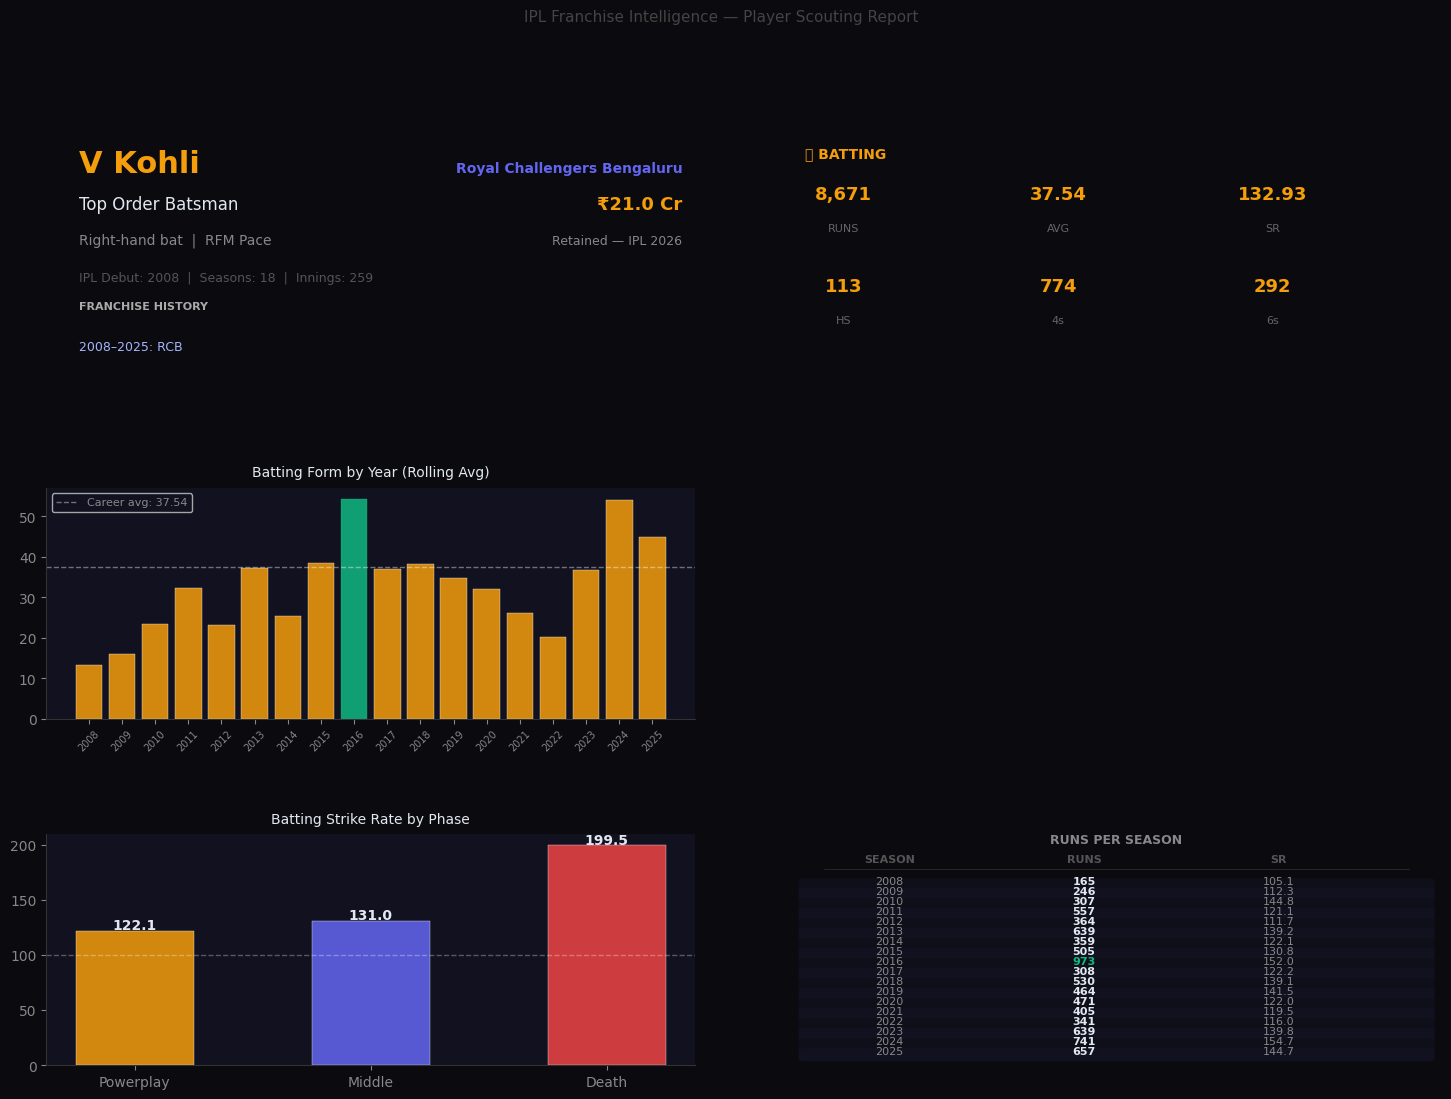

✅ Saved: ../reports/player_card_JJ_Bumrah.png


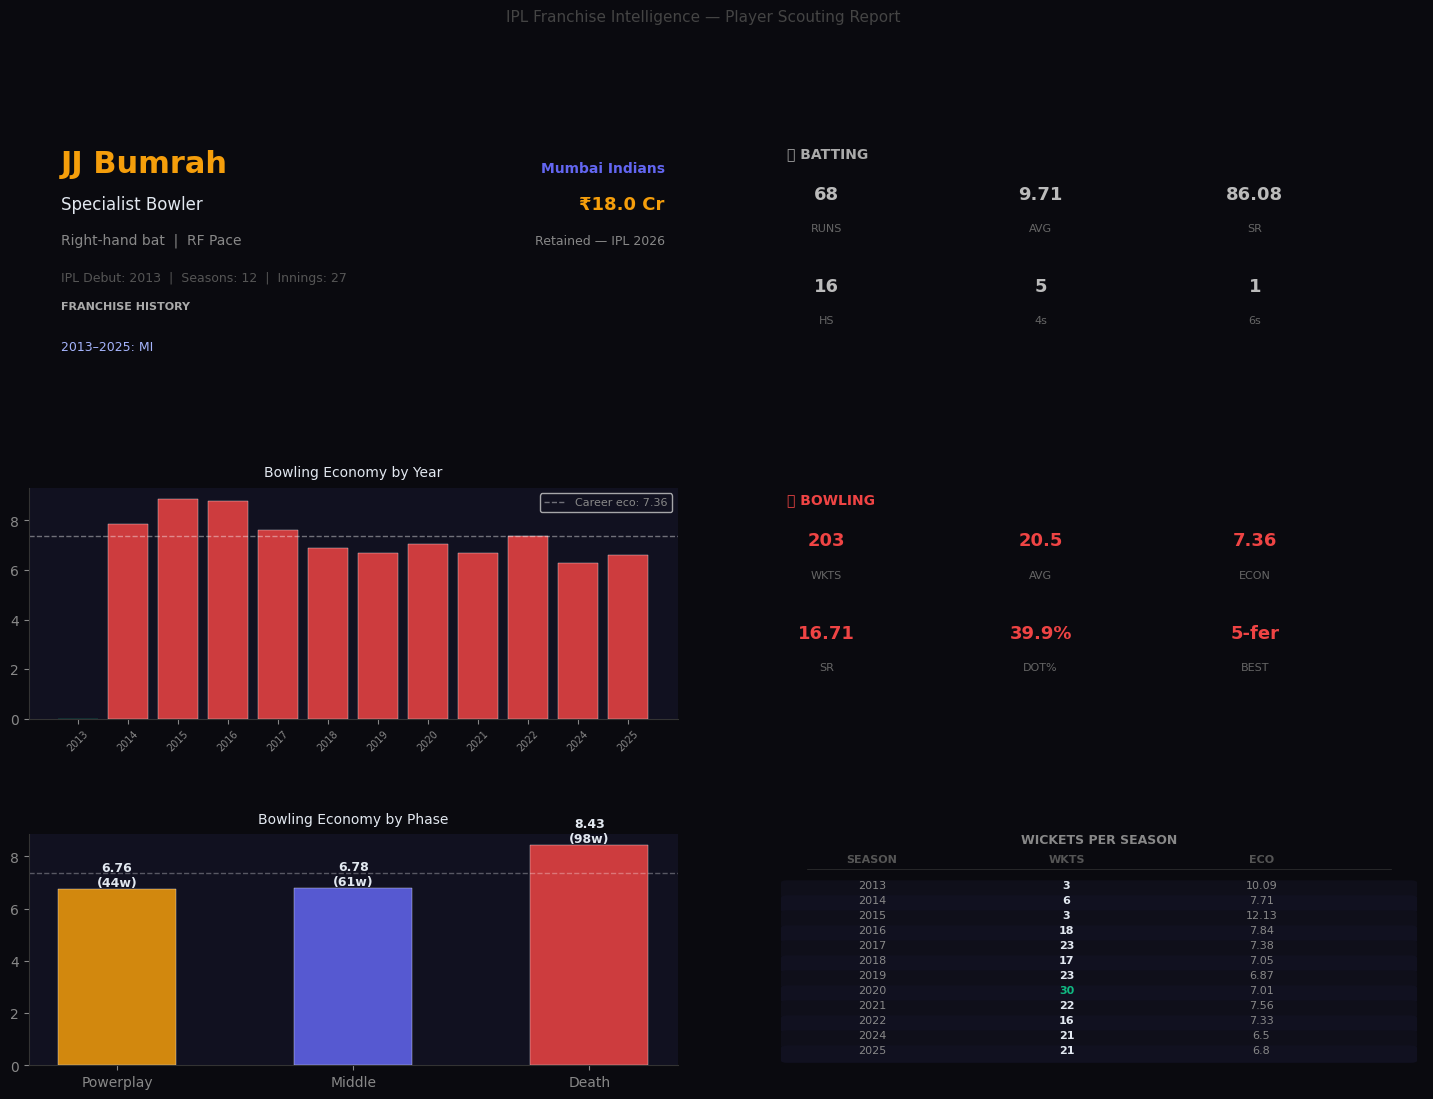

✅ Saved: ../reports/player_card_MS_Dhoni.png


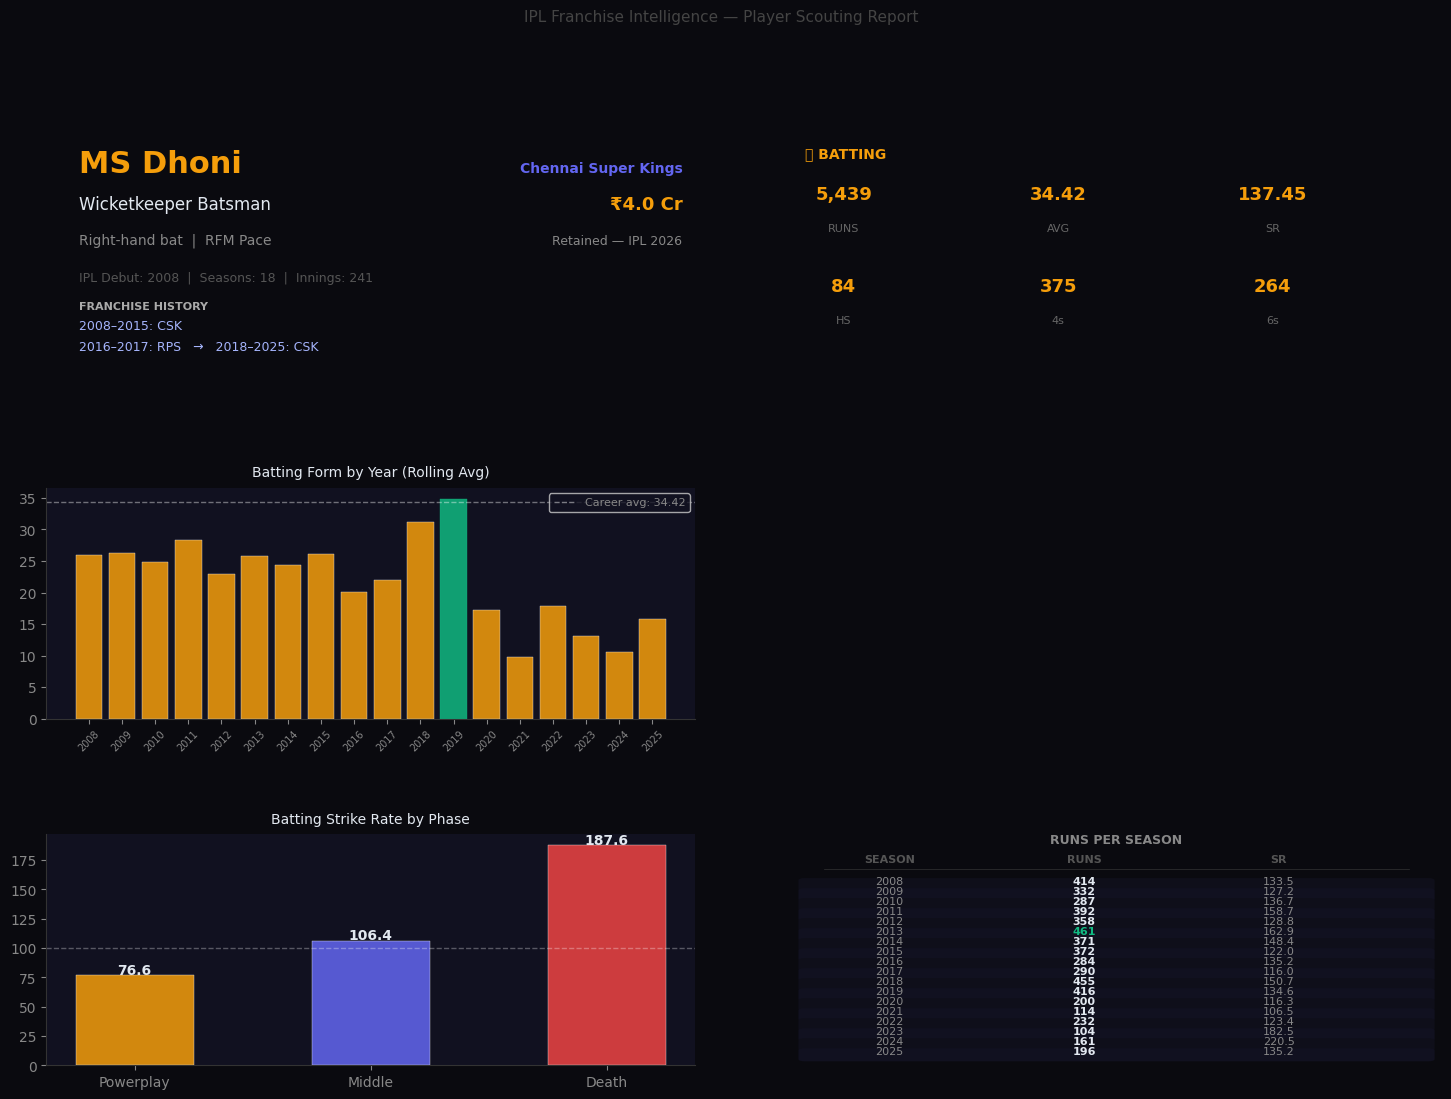

✅ Saved: ../reports/player_card_KL_Rahul.png


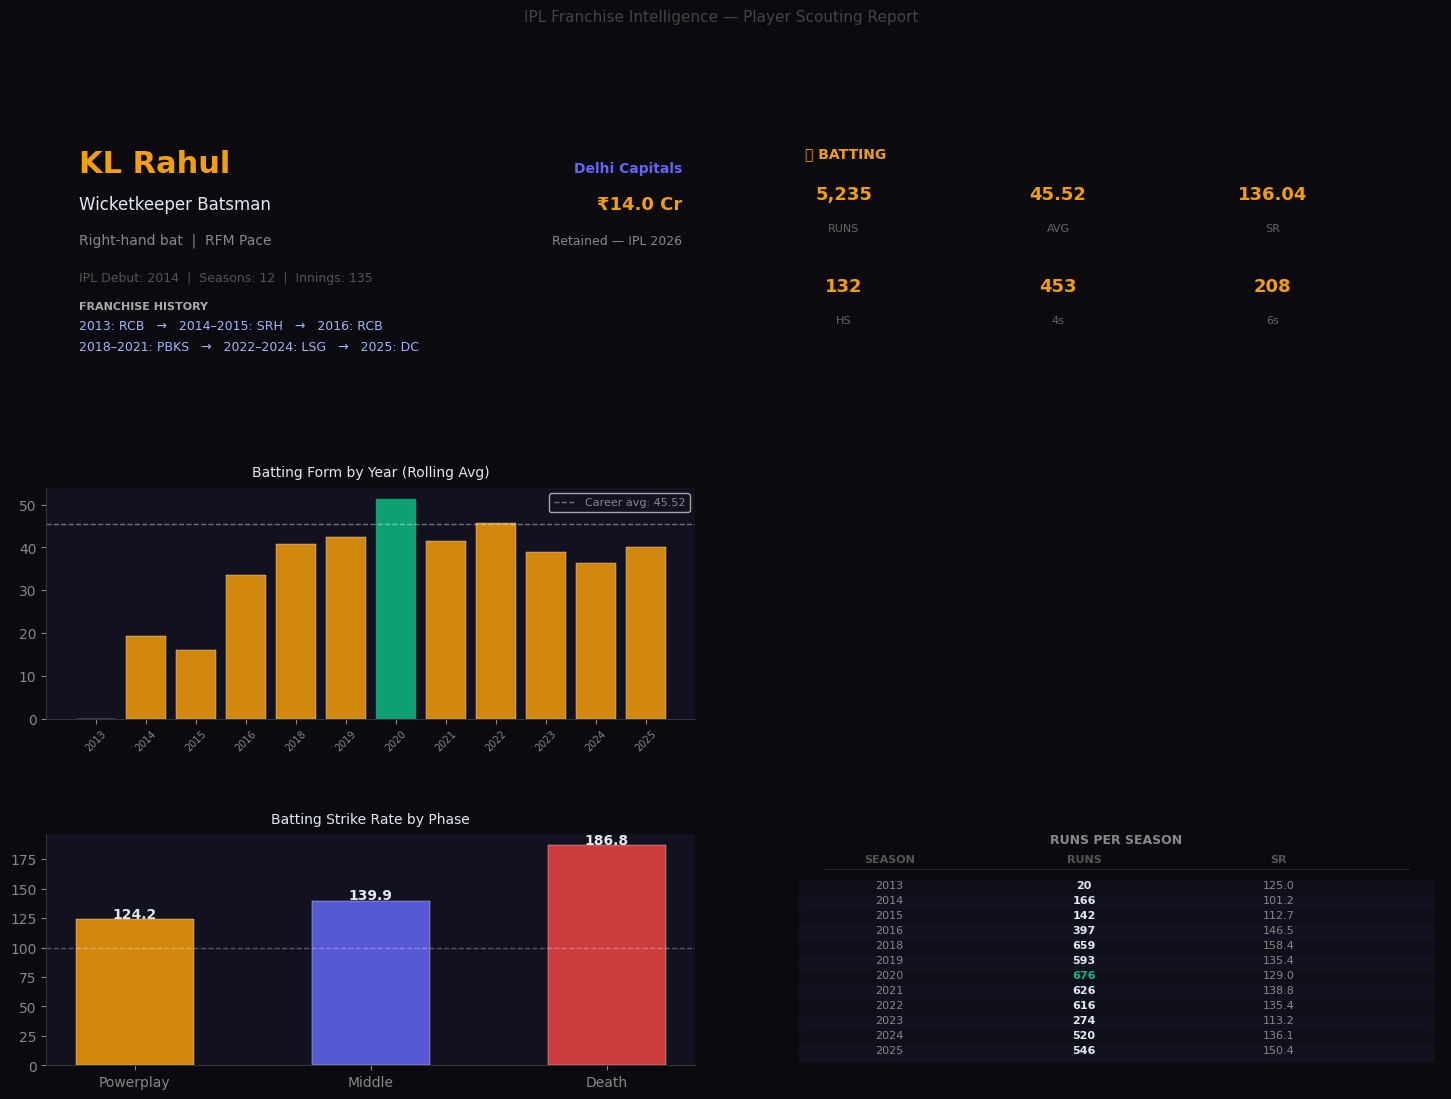

In [58]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import numpy as np

def generate_player_card(player_name, save=True):
    
    career_info = player_career_info[player_career_info['player'] == player_name]
    bat_history = batting_features[batting_features['batsman'] == player_name].sort_values('date')
    bowl_history = bowling_features[bowling_features['bowler'] == player_name].sort_values('date')
    metadata = final_metadata_df[final_metadata_df['player'] == player_name]

    if len(career_info) == 0:
        print(f"Player {player_name} not found!")
        return

    career = career_info.iloc[0]

    # ── ROLE & METADATA ────────────────────────────────
    role = metadata['role'].values[0] if len(metadata) > 0 else 'Unknown'
    bat_hand = metadata['batting_hand'].values[0] if len(metadata) > 0 else 'R'
    bowl_style = metadata['bowling_style'].values[0] if len(metadata) > 0 else ''
    bowl_type = metadata['bowling_type'].values[0] if len(metadata) > 0 else ''

    is_primary_batter = role in ['Opener', 'Top Order Batsman', 'Middle Order Batsman',
                                  'Finisher', 'Wicketkeeper Batsman', 'Batting Allrounder',
                                  'Batsman']
    is_primary_bowler = role in ['Specialist Bowler', 'Bowling Allrounder', 'Bowler']
    is_allrounder = 'Allrounder' in role

    # ── BATTING STATS ──────────────────────────────────
    player_bat = master[(master['batsman'] == player_name) & (master['is_wide'] == 0)]
    has_batting = len(player_bat) > 0 and player_bat['batsman_runs'].sum() >= 50

    if has_batting:
        total_runs = player_bat['batsman_runs'].sum()
        total_innings = player_bat['matchId'].nunique()
        total_balls = len(player_bat)
        total_fours = (player_bat['batsman_runs'] == 4).sum()
        total_sixes = (player_bat['batsman_runs'] == 6).sum()
        dismissals = player_bat['is_wicket'].sum()
        career_avg = round(total_runs / max(dismissals, 1), 2)
        career_sr = round(total_runs / max(total_balls, 1) * 100, 2)
        highest_score = player_bat.groupby('matchId')['batsman_runs'].sum().max()
        season_runs = (master[(master['batsman']==player_name) & (master['is_wide']==0)]
                      .groupby('season')['batsman_runs'].sum().sort_index())
        phases = ['Powerplay', 'Middle', 'Death']
        phase_sr = []
        for phase in phases:
            pb = player_bat[master.loc[player_bat.index, 'phase'] == phase]
            p_runs = pb['batsman_runs'].sum()
            p_balls = len(pb)
            phase_sr.append(round(p_runs / max(p_balls, 1) * 100, 1))
    
    # ── BOWLING STATS ──────────────────────────────────
    player_bowl = master[master['bowler'] == player_name]
    player_bowl_legal = player_bowl[player_bowl['is_wide'] == 0]
    total_wickets = player_bowl['is_wicket'].sum()
    has_bowling = (total_wickets >= 20 and len(player_bowl_legal) >= 120) or \
              (is_primary_bowler and total_wickets >= 5)

    if has_bowling:
        total_balls_bowled = len(player_bowl_legal)
        runs_conceded = player_bowl['total_runs'].sum()
        economy = round(runs_conceded / max(total_balls_bowled/6, 0.1), 2)
        bowl_avg = round(runs_conceded / max(total_wickets, 1), 2)
        bowl_sr = round(total_balls_bowled / max(total_wickets, 1), 2)
        dot_pct = round((player_bowl_legal['total_runs'] == 0).sum() /
                        max(total_balls_bowled, 1) * 100, 1)
        best_match = (player_bowl[player_bowl['is_wicket']==1]
                     .groupby('matchId')['is_wicket'].sum().max())
        season_wkts = (master[master['bowler']==player_name]
                      .groupby('season')['is_wicket'].sum().sort_index())
        
        # Phase bowling
        phase_eco, phase_wkts_list = [], []
        for phase in ['Powerplay', 'Middle', 'Death']:
            pw = player_bowl[master.loc[player_bowl.index, 'phase'] == phase]
            pw_legal = player_bowl_legal[master.loc[player_bowl_legal.index, 'phase'] == phase]
            w = pw['is_wicket'].sum()
            r = pw['total_runs'].sum()
            b = len(pw_legal)
            phase_eco.append(round(r / max(b/6, 0.1), 2))
            phase_wkts_list.append(int(w))

    


    franchise = career.get('current_franchise', 'N/A')
    price = career.get('latest_price_cr', 'N/A')
    acquisition = career.get('how_acquired', 'N/A')
    debut = int(career.get('debut_season', 0)) if pd.notna(career.get('debut_season')) else 'N/A'
    seasons = int(career.get('seasons_played', 0)) if pd.notna(career.get('seasons_played')) else 'N/A'
    total_innings = player_bat['matchId'].nunique() if has_batting else 0

    # ── COLORS ─────────────────────────────────────────
    primary_c = '#F59E0B'
    secondary_c = '#6366F1'
    bowl_c = '#EF4444'
    bg = '#0a0a0f'
    card_bg = '#111120'
    text_col = '#e2e8f0'

    fig = plt.figure(figsize=(18, 12), facecolor=bg)
    gs = gridspec.GridSpec(3, 4, figure=fig, hspace=0.5, wspace=0.35)

    # ── HEADER ─────────────────────────────────────────
    ax_header = fig.add_subplot(gs[0, :2])
    ax_header.set_facecolor(card_bg)
    ax_header.set_xlim(0, 1)
    ax_header.set_ylim(0, 1)
    ax_header.axis('off')
    ax_header.text(0.05, 0.82, player_name, fontsize=22, fontweight='bold',
                   color=primary_c)
    ax_header.text(0.05, 0.60, role, fontsize=12, color=text_col)
    ax_header.text(0.05, 0.40,
                   f"{'Left' if bat_hand=='L' else 'Right'}-hand bat  |  {bowl_style} {bowl_type}",
                   fontsize=10, color='#888')
    ax_header.text(0.05, 0.18,
                   f"IPL Debut: {debut}  |  Seasons: {seasons}  |  Innings: {total_innings}",
                   fontsize=9, color='#555')
    if pd.notna(franchise) and str(franchise) not in ['N/A', 'nan']:
        ax_header.text(0.98, 0.82, str(franchise), fontsize=10,
                       fontweight='bold', color=secondary_c, ha='right')
        if pd.notna(price) and price != 'N/A':
            ax_header.text(0.98, 0.60, f"₹{price} Cr", fontsize=13,
                           fontweight='bold', color=primary_c, ha='right')
        ax_header.text(0.98, 0.40, str(acquisition), fontsize=9,
                       color='#888', ha='right')

    # ── BATTING STATS (shown if has batting) ───────────
    if has_batting:
        ax_bat = fig.add_subplot(gs[0, 2:])
        ax_bat.set_facecolor(card_bg)
        ax_bat.axis('off')
        ax_bat.set_xlim(0, 1)
        ax_bat.set_ylim(0, 1)
        title_col = primary_c if is_primary_batter or is_allrounder else '#aaa'
        ax_bat.text(0.02, 0.93, '🏏 BATTING', fontsize=10,
                    color=title_col, fontweight='bold')
        bat_stats = [
            ('RUNS', f'{total_runs:,}'), ('AVG', f'{career_avg}'),
            ('SR', f'{career_sr}'), ('HS', f'{int(highest_score)}'),
            ('4s', f'{total_fours:,}'), ('6s', f'{total_sixes:,}'),
        ]
        for idx, (label, val) in enumerate(bat_stats):
            x = 0.08 + (idx % 3) * 0.33
            y = 0.65 if idx < 3 else 0.25
            val_col = primary_c if (is_primary_batter or is_allrounder) else '#bbb'
            ax_bat.text(x, y+0.10, val, fontsize=13, fontweight='bold',
                        color=val_col, ha='center')
            ax_bat.text(x, y-0.04, label, fontsize=8, color='#666', ha='center')

    # ── BOWLING STATS (shown if has bowling) ───────────
    if has_bowling:
        row = 0 if not has_batting else 1
        col = 2 if not has_batting else 2
        ax_bowl_stats = fig.add_subplot(gs[row if not has_batting else 1, 2:])
        ax_bowl_stats.set_facecolor(card_bg)
        ax_bowl_stats.axis('off')
        ax_bowl_stats.set_xlim(0, 1)
        ax_bowl_stats.set_ylim(0, 1)
        title_col = bowl_c if is_primary_bowler or is_allrounder else '#aaa'
        ax_bowl_stats.text(0.02, 0.93, '🎳 BOWLING', fontsize=10,
                           color=title_col, fontweight='bold')
        bowl_stats = [
            ('WKTS', f'{total_wickets}'), ('AVG', f'{bowl_avg}'),
            ('ECON', f'{economy}'), ('SR', f'{bowl_sr}'),
            ('DOT%', f'{dot_pct}%'), ('BEST', f'{int(best_match)}-fer'),
        ]
        for idx, (label, val) in enumerate(bowl_stats):
            x = 0.08 + (idx % 3) * 0.33
            y = 0.65 if idx < 3 else 0.25
            val_col = bowl_c if (is_primary_bowler or is_allrounder) else '#bbb'
            ax_bowl_stats.text(x, y+0.10, val, fontsize=13, fontweight='bold',
                               color=val_col, ha='center')
            ax_bowl_stats.text(x, y-0.04, label, fontsize=8,
                               color='#666', ha='center')

    # ── FORM TRAJECTORY (batting or bowling based on role) ──
    ax_form = fig.add_subplot(gs[1, :2])
    ax_form.set_facecolor(card_bg)

    if is_primary_bowler and has_bowling and len(bowl_history) > 3:
        # Bowling form — economy by year
        bowl_history['date'] = pd.to_datetime(bowl_history['date'])
        bowl_history['year'] = bowl_history['date'].dt.year
        yearly_eco = bowl_history.groupby('year')['form_economy'].mean().reset_index()
        bars = ax_form.bar(yearly_eco['year'].astype(str), yearly_eco['form_economy'],
                          color=bowl_c, alpha=0.85, edgecolor='white', linewidth=0.3)
        ax_form.axhline(economy, color='white', linestyle='--', alpha=0.4,
                       linewidth=1, label=f'Career eco: {economy}')
        best_idx = yearly_eco['form_economy'].idxmin()  # lower is better
        bars[best_idx].set_color('#10B981')
        ax_form.set_title('Bowling Economy by Year', color=text_col, fontsize=10, pad=8)
        ax_form.legend(fontsize=8, labelcolor='#888', facecolor=card_bg)
    elif has_batting and len(bat_history) > 3:
        # Batting form by year
        bat_history['date'] = pd.to_datetime(bat_history['date'])
        bat_history['year'] = bat_history['date'].dt.year
        yearly_form = bat_history.groupby('year')['avg_last5'].mean().reset_index()
        bars = ax_form.bar(yearly_form['year'].astype(str), yearly_form['avg_last5'],
                          color=primary_c, alpha=0.85, edgecolor='white', linewidth=0.3)
        ax_form.axhline(career_avg, color='white', linestyle='--', alpha=0.4,
                       linewidth=1, label=f'Career avg: {career_avg}')
        best_idx = yearly_form['avg_last5'].idxmax()
        bars[best_idx].set_color('#10B981')
        ax_form.set_title('Batting Form by Year (Rolling Avg)', 
                          color=text_col, fontsize=10, pad=8)
        ax_form.legend(fontsize=8, labelcolor='#888', facecolor=card_bg)

    ax_form.tick_params(axis='x', rotation=45, labelsize=7, colors='#888')
    ax_form.tick_params(axis='y', colors='#888')
    for spine in ['bottom', 'left']:
        ax_form.spines[spine].set_color('#333')
    ax_form.spines['top'].set_visible(False)
    ax_form.spines['right'].set_visible(False)

    # ── PHASE CHART (batting SR or bowling economy) ────
    ax_phase = fig.add_subplot(gs[2, :2])
    ax_phase.set_facecolor(card_bg)
    phases = ['Powerplay', 'Middle', 'Death']
    phase_colors = [primary_c, secondary_c, '#EF4444']

    if is_primary_bowler and has_bowling:
        bars = ax_phase.bar(phases, phase_eco, color=phase_colors,
                           edgecolor='white', linewidth=0.3, alpha=0.85, width=0.5)
        ax_phase.axhline(economy, color='white', linestyle='--',
                        alpha=0.3, linewidth=1, label=f'Overall eco: {economy}')
        ax_phase.set_title('Bowling Economy by Phase', color=text_col, fontsize=10, pad=8)
        for bar, val, wk in zip(bars, phase_eco, phase_wkts_list):
            ax_phase.text(bar.get_x() + bar.get_width()/2,
                         bar.get_height() + 0.1,
                         f'{val}\n({wk}w)', ha='center', fontsize=9,
                         color=text_col, fontweight='bold')
    elif has_batting:
        bars = ax_phase.bar(phases, phase_sr, color=phase_colors,
                           edgecolor='white', linewidth=0.3, alpha=0.85, width=0.5)
        ax_phase.axhline(100, color='white', linestyle='--', alpha=0.3, linewidth=1)
        ax_phase.set_title('Batting Strike Rate by Phase', 
                           color=text_col, fontsize=10, pad=8)
        for bar, val in zip(bars, phase_sr):
            ax_phase.text(bar.get_x() + bar.get_width()/2,
                         bar.get_height() + 1, f'{val}',
                         ha='center', fontsize=10, color=text_col, fontweight='bold')

    ax_phase.set_facecolor(card_bg)
    ax_phase.tick_params(colors='#888')
    for spine in ['bottom', 'left']:
        ax_phase.spines[spine].set_color('#333')
    ax_phase.spines['top'].set_visible(False)
    ax_phase.spines['right'].set_visible(False)

    # ── SEASON LIST (runs or wickets) ──────────────────
    ax_list = fig.add_subplot(gs[2, 2:])
    ax_list.set_facecolor(card_bg)
    ax_list.axis('off')
    ax_list.set_xlim(0, 1)
    ax_list.set_ylim(0, 1)

    if is_primary_bowler and has_bowling:
        ax_list.text(0.5, 0.96, 'WICKETS PER SEASON', fontsize=9,
                    color='#888', ha='center', fontweight='bold')
        seasons_list = season_wkts.items()
        col1_label, col2_label = 'SEASON', 'WKTS'
        col2_data = season_wkts
    elif has_batting:
        ax_list.text(0.5, 0.96, 'RUNS PER SEASON', fontsize=9,
                    color='#888', ha='center', fontweight='bold')
        col2_data = season_runs

    # Headers
    ax_list.text(0.15, 0.88, 'SEASON', fontsize=8, color='#555',
                ha='center', fontweight='bold')
    ax_list.text(0.45, 0.88, 'RUNS' if not is_primary_bowler else 'WKTS',
                fontsize=8, color='#555', ha='center', fontweight='bold')
    if has_batting and not is_primary_bowler:
        ax_list.text(0.75, 0.88, 'SR', fontsize=8, color='#555',
                    ha='center', fontweight='bold')
    elif has_bowling:
        ax_list.text(0.75, 0.88, 'ECO', fontsize=8, color='#555',
                    ha='center', fontweight='bold')

    # Draw separator line
    ax_list.axhline(0.85, color='#333', linewidth=0.5, xmin=0.05, xmax=0.95)

    # Season data rows (show last 12 seasons)
    data_to_show = col2_data  # show all seasons
    total_rows = len(data_to_show)
    row_height = 0.78 / max(total_rows, 1)

    for i, (season, val) in enumerate(data_to_show.items()):
        y = 0.82 - (i + 1) * row_height
        row_bg = '#0f0f1a' if i % 2 == 0 else card_bg
        ax_list.add_patch(mpatches.FancyBboxPatch(
            (0.02, y - row_height*0.3), 0.96, row_height*0.85,
            boxstyle="round,pad=0.01", facecolor=row_bg, edgecolor='none'))

        ax_list.text(0.15, y + row_height*0.2, str(int(season)),
                    fontsize=8, color='#888', ha='center')

        if is_primary_bowler and has_bowling:
            val_col = '#10B981' if val == data_to_show.max() else text_col
            ax_list.text(0.45, y + row_height*0.2, str(int(val)),
                        fontsize=8, color=val_col, ha='center', fontweight='bold')
            # Economy that season
            season_bowl = master[(master['bowler']==player_name) &
                                 (master['season']==season)]
            season_legal = season_bowl[season_bowl['is_wide']==0]
            s_eco = round(season_bowl['total_runs'].sum() /
                         max(len(season_legal)/6, 0.1), 2)
            ax_list.text(0.75, y + row_height*0.2, str(s_eco),
                        fontsize=8, color='#888', ha='center')
        elif has_batting:
            val_col = '#10B981' if val == data_to_show.max() else text_col
            ax_list.text(0.45, y + row_height*0.2, str(int(val)),
                        fontsize=8, color=val_col, ha='center', fontweight='bold')
            # SR that season
            season_bat = master[(master['batsman']==player_name) &
                               (master['season']==season) &
                               (master['is_wide']==0)]
            s_sr = round(season_bat['batsman_runs'].sum() /
                        max(len(season_bat), 1) * 100, 1)
            ax_list.text(0.75, y + row_height*0.2, str(s_sr),
                        fontsize=8, color='#888', ha='center')
    
    # ── TRANSFER HISTORY ──────────────────────────────
    team_abbr = {
        'Royal Challengers Bengaluru': 'RCB',
        'Mumbai Indians': 'MI',
        'Chennai Super Kings': 'CSK',
        'Kolkata Knight Riders': 'KKR',
        'Delhi Capitals': 'DC',
        'Delhi Daredevils': 'DC',
        'Sunrisers Hyderabad': 'SRH',
        'Punjab Kings': 'PBKS',
        'Kings XI Punjab': 'PBKS',
        'Rajasthan Royals': 'RR',
        'Gujarat Titans': 'GT',
        'Lucknow Super Giants': 'LSG',
        'Rising Pune Supergiant': 'RPS',
        'Pune Warriors India': 'PWI',
        'Kochi Tuskers Kerala': 'KTK',
        'Deccan Chargers': 'DC2',
        'Gujarat Lions': 'GL',
    }

    history_str = career.get('franchise_history', '')
    if history_str:
        entries = history_str.split(' → ')
        grouped = []
        for entry in entries:
            if ':' in entry:
                yr, team = entry.split(':', 1)
                abbr = team_abbr.get(team, team[:4])
                if grouped and grouped[-1][1] == abbr:
                    start_yr = grouped[-1][0].split('–')[0]
                    grouped[-1] = (f"{start_yr}–{yr}", abbr)
                else:
                    grouped.append((yr, abbr))

        mid = len(grouped) // 2
        line1 = '   →   '.join([f"{yr}: {abbr}" for yr, abbr in grouped[:mid]])
        line2 = '   →   '.join([f"{yr}: {abbr}" for yr, abbr in grouped[mid:]])

        ax_header.set_ylim(-0.35, 1)
        ax_header.text(0.05, 0.02, 'FRANCHISE HISTORY',
                      fontsize=8, color='#aaaaaa', fontweight='bold')
        ax_header.text(0.05, -0.10, line1, fontsize=9, color='#a5b4fc')
        ax_header.text(0.05, -0.22, line2, fontsize=9, color='#a5b4fc')

    plt.suptitle('IPL Franchise Intelligence — Player Scouting Report',
                fontsize=11, color='#444', y=0.99)

    if save:
        filename = f"../reports/player_card_{player_name.replace(' ','_')}.png"
        plt.savefig(filename, dpi=150, bbox_inches='tight', facecolor=bg)
        print(f"✅ Saved: {filename}")

    plt.show()
    return fig

# Test on different player types
for player in ['V Kohli', 'JJ Bumrah', 'MS Dhoni', 'KL Rahul']:
    generate_player_card(player)
    plt.close()


In [29]:

auction_2026_names = auction_2026['full_name'].tolist()

def get_acquisition_label(row):
    auction_name = row.get('auction_name', '')
    if pd.isna(auction_name):
        return row.get('how_acquired', 'Unknown')
    
    # Check if in 2026 auction
    if auction_name in auction_2026_names:
        return 'Bought 2026'
    
    # Check if retained in 2025 (Base was hyphen)
    retained_2025 = auction_2025[auction_2025['is_retained_2025'] == True]['full_name'].tolist()
    if auction_name in retained_2025:
        return 'Retained 2025'
    
    # Otherwise bought in 2025
    how = row.get('how_acquired', '')
    if pd.notna(how) and how != 'nan':
        return how
    
    return 'Bought 2025'

player_career_info['how_acquired'] = player_career_info.apply(
    get_acquisition_label, axis=1)

# Save
player_career_info.to_csv('../data/player_career_info.csv', index=False)

# Verify
sample = ['V Kohli', 'JJ Bumrah', 'RR Pant', 'YBK Jaiswal',
          'Shubman Gill', 'YS Chahal', 'Arshdeep Singh',
          'Ravi Bishnoi', 'Cameron Green', 'Matheesha Pathirana']
print(player_career_info[player_career_info['player'].isin(sample) |
                          player_career_info['auction_name'].isin(sample)][
    ['player', 'auction_name', 'current_franchise', 
     'latest_price_cr', 'how_acquired']
].to_string())

             player      auction_name            current_franchise  latest_price_cr   how_acquired
91   Arshdeep Singh    Arshdeep Singh                 Punjab Kings             18.0    Bought 2025
279       JJ Bumrah    Jasprit Bumrah               Mumbai Indians             18.0  Retained 2025
511       R Bishnoi      Ravi Bishnoi             Rajasthan Royals              7.2    Bought 2026
554         RR Pant      Rishabh Pant         Lucknow Super Giants             27.0    Bought 2025
571    Ravi Bishnoi      Ravi Bishnoi             Rajasthan Royals              7.2    Bought 2026
666    Shubman Gill      Shubman Gill               Gujarat Titans             16.5  Retained 2025
710         V Kohli       Virat Kohli  Royal Challengers Bengaluru             21.0  Retained 2025
746     YBK Jaiswal  Yashasvi Jaiswal             Rajasthan Royals             18.0  Retained 2025
748       YS Chahal  Yuzvendra Chahal                 Punjab Kings             18.0    Bought 2025


In [30]:
# Fix 1: Season year correction (2007 → 2008 in our data)
player_career_info['debut_season'] = player_career_info['debut_season'].replace(2007, 2008)
player_career_info['last_ipl_season'] = player_career_info['last_ipl_season'].replace(2007, 2008)

# Fix season in master dataframe too
master['season'] = master['season'].replace(2007, 2008)
matches['season'] = matches['season'].replace(2007, 2008)

# Fix 2: Acquisition label on card
# Already handled by how_acquired column
# But let's make sure display is clean
player_career_info['how_acquired'] = player_career_info['how_acquired'].replace({
    'Retained 2025': 'Retained — IPL 2025',
    'Bought 2025': 'Bought — IPL 2025 Auction',
    'Bought 2026': 'Bought — IPL 2026 Auction',
})

# Save
player_career_info.to_csv('../data/player_career_info.csv', index=False)
master.to_csv('../data/master_ipl.csv', index=False)
matches.to_csv('../data/matches_clean.csv', index=False)

print("Fixed!")
print("\nSample:")
sample = ['V Kohli', 'MS Dhoni', 'RG Sharma', 'YBK Jaiswal', 
          'Ravi Bishnoi', 'Arshdeep Singh']
print(player_career_info[player_career_info['player'].isin(sample)][
    ['player', 'debut_season', 'current_franchise', 
     'how_acquired', 'latest_price_cr']
].to_string())

Fixed!

Sample:
             player  debut_season            current_franchise               how_acquired  latest_price_cr
91   Arshdeep Singh        2019.0                 Punjab Kings  Bought — IPL 2025 Auction             18.0
417        MS Dhoni        2008.0          Chennai Super Kings        Retained — IPL 2025              4.0
540       RG Sharma        2008.0               Mumbai Indians        Retained — IPL 2025             16.3
571    Ravi Bishnoi        2020.0             Rajasthan Royals  Bought — IPL 2026 Auction              7.2
710         V Kohli        2008.0  Royal Challengers Bengaluru        Retained — IPL 2025             21.0
746     YBK Jaiswal        2020.0             Rajasthan Royals        Retained — IPL 2025             18.0


In [32]:
# Build retained 2026 list
squad_2025_names = auction_2025[auction_2025['Team'] != '-']['full_name'].tolist()
bought_2026_names = auction_2026['full_name'].tolist()
retained_2026_names = [p for p in squad_2025_names if p not in bought_2026_names]

print(f"Retained for 2026: {len(retained_2026_names)}")
print(f"Bought in 2026: {len(bought_2026_names)}")

# Update how_acquired
def get_final_acquisition(row):
    auction_name = row.get('auction_name', '')
    if pd.isna(auction_name) or auction_name == 'nan':
        return 'Unknown'
    
    if auction_name in bought_2026_names:
        return 'Bought — IPL 2026 Auction'
    elif auction_name in retained_2026_names:
        return 'Retained — IPL 2026'
    else:
        # Check if retained in 2025 mega auction
        retained_2025 = auction_2025[
            auction_2025['is_retained_2025'] == True]['full_name'].tolist()
        if auction_name in retained_2025:
            return 'Retained — IPL 2025'
        elif auction_name in squad_2025_names:
            return 'Bought — IPL 2025 Auction'
        else:
            return 'Unknown'

player_career_info['how_acquired'] = player_career_info.apply(
    get_final_acquisition, axis=1)

# Save
player_career_info.to_csv('../data/player_career_info.csv', index=False)

# Verify
sample = ['V Kohli', 'JJ Bumrah', 'MS Dhoni', 'RR Pant',
          'YBK Jaiswal', 'Arshdeep Singh', 'Ravi Bishnoi',
          'Shubman Gill', 'HH Pandya', 'RA Jadeja']
print("\nSample players:")
print(player_career_info[player_career_info['player'].isin(sample)][
    ['player', 'current_franchise', 'latest_price_cr', 'how_acquired']
].to_string())

Retained for 2026: 210
Bought in 2026: 77

Sample players:
             player            current_franchise  latest_price_cr               how_acquired
91   Arshdeep Singh                 Punjab Kings            18.00        Retained — IPL 2026
235       HH Pandya               Mumbai Indians            16.35        Retained — IPL 2026
279       JJ Bumrah               Mumbai Indians            18.00        Retained — IPL 2026
417        MS Dhoni          Chennai Super Kings             4.00        Retained — IPL 2026
531       RA Jadeja          Chennai Super Kings            18.00        Retained — IPL 2026
554         RR Pant         Lucknow Super Giants            27.00        Retained — IPL 2026
571    Ravi Bishnoi             Rajasthan Royals             7.20  Bought — IPL 2026 Auction
666    Shubman Gill               Gujarat Titans            16.50        Retained — IPL 2026
710         V Kohli  Royal Challengers Bengaluru            21.00        Retained — IPL 2026
746     YBK

In [34]:

print("=== SAMSON CHECK ===")
samson_variants = master[master['batsman'].str.contains('Samson', na=False)]['batsman'].unique()
print("Samson name variants in data:", samson_variants)

print("\n=== SEASONS CHECK ===")
kohli_seasons = master[master['batsman']=='V Kohli']['season'].unique()
print(f"Kohli seasons in data: {sorted(kohli_seasons)}")
print(f"Total unique seasons in master: {sorted(master['season'].unique())}")

print("\n=== CAREER INFO SEASONS CHECK ===")
kohli_info = player_career_info[player_career_info['player']=='V Kohli']
print(f"Kohli debut: {kohli_info['debut_season'].values}")
print(f"Kohli last season: {kohli_info['last_ipl_season'].values}")
print(f"Kohli seasons played: {kohli_info['seasons_played'].values}")

=== SAMSON CHECK ===
Samson name variants in data: ['SV Samson']

=== SEASONS CHECK ===
Kohli seasons in data: [np.float64(2008.0), np.float64(2009.0), np.float64(2011.0), np.float64(2012.0), np.float64(2013.0), np.float64(nan), np.float64(2014.0), np.float64(2015.0), np.float64(2016.0), np.float64(2017.0), np.float64(2018.0), np.float64(2019.0), np.float64(2020.0), np.float64(2021.0), np.float64(2022.0), np.float64(2023.0), np.float64(2024.0), np.float64(2025.0)]
Total unique seasons in master: [np.float64(2008.0), np.float64(2009.0), np.float64(nan), np.float64(2011.0), np.float64(2012.0), np.float64(2013.0), np.float64(2014.0), np.float64(2015.0), np.float64(2016.0), np.float64(2017.0), np.float64(2018.0), np.float64(2019.0), np.float64(2020.0), np.float64(2021.0), np.float64(2022.0), np.float64(2023.0), np.float64(2024.0), np.float64(2025.0)]

=== CAREER INFO SEASONS CHECK ===
Kohli debut: [2008.]
Kohli last season: [2025.]
Kohli seasons played: [17]


In [35]:
# Fix 1: NaN season — it's the 2010 season missing from dataset
master['date'] = pd.to_datetime(master['date'])
master['season'] = master['season'].fillna(
    master['date'].dt.year.apply(lambda y: 2010 if y == 2010 else y)
)

# Recount seasons played
player_teams_fixed = (master.groupby(['season', 'batsman', 'batting_team'])
                      .size().reset_index(name='balls'))
player_teams_fixed = player_teams_fixed[player_teams_fixed['balls'] >= 5]
player_teams_fixed.rename(columns={'batsman': 'player', 
                                    'batting_team': 'team'}, inplace=True)

bowler_teams_fixed = (master.groupby(['season', 'bowler', 'bowling_team'])
                      .size().reset_index(name='balls'))
bowler_teams_fixed = bowler_teams_fixed[bowler_teams_fixed['balls'] >= 5]
bowler_teams_fixed.rename(columns={'bowler': 'player', 
                                    'bowling_team': 'team'}, inplace=True)

all_teams_fixed = pd.concat([player_teams_fixed, bowler_teams_fixed]).drop_duplicates(
    subset=['season', 'player', 'team'])

# Recount seasons
seasons_fixed = (all_teams_fixed.groupby('player')['season']
                 .nunique().reset_index())
seasons_fixed.columns = ['player', 'seasons_played']

# Rebuild transfer history
transfer_fixed = (all_teams_fixed.sort_values('season')
                  .groupby('player')
                  .apply(lambda x: ' → '.join(
                      [f"{int(row['season'])}:{row['team']}"
                       for _, row in x.iterrows()]
                  )).reset_index())
transfer_fixed.columns = ['player', 'franchise_history']

# Update player_career_info
player_career_info = player_career_info.drop(
    columns=['seasons_played', 'franchise_history'], errors='ignore')
player_career_info = player_career_info.merge(seasons_fixed, on='player', how='left')
player_career_info = player_career_info.merge(transfer_fixed, on='player', how='left')

# Fix 2: Add SV Samson to final_metadata_df if missing
if 'SV Samson' not in final_metadata_df['player'].values:
    new_row = pd.DataFrame([{
        'player': 'SV Samson',
        'batting_hand': 'R',
        'bowling_style': 'OB',
        'bowling_type': 'Spin',
        'role': 'Wicketkeeper Batsman'
    }])
    final_metadata_df = pd.concat([final_metadata_df, new_row], 
                                   ignore_index=True)
    print("Added SV Samson to metadata")

# Save
player_career_info.to_csv('../data/player_career_info.csv', index=False)
master.to_csv('../data/master_ipl.csv', index=False)

# Verify
sample = ['V Kohli', 'MS Dhoni', 'RG Sharma', 'SV Samson', 'DA Warner']
print("=== FIXED SEASONS ===")
print(player_career_info[player_career_info['player'].isin(sample)][
    ['player', 'debut_season', 'last_ipl_season', 
     'seasons_played', 'franchise_history']
].to_string())

=== FIXED SEASONS ===
        player  debut_season  last_ipl_season  seasons_played                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                 franchise_history
163  DA Warner        2009.0           2024.0              14                                                                                                                                                                                                                                                              2009:De

In [36]:
print("Seasons in dataset:", sorted([s for s in master['season'].unique() 
                                      if pd.notna(s)]))
print("\nIs 2010 missing from dataset?", 
      2010 not in master['season'].unique())

Seasons in dataset: [np.float64(2008.0), np.float64(2009.0), np.float64(2010.0), np.float64(2011.0), np.float64(2012.0), np.float64(2013.0), np.float64(2014.0), np.float64(2015.0), np.float64(2016.0), np.float64(2017.0), np.float64(2018.0), np.float64(2019.0), np.float64(2020.0), np.float64(2021.0), np.float64(2022.0), np.float64(2023.0), np.float64(2024.0), np.float64(2025.0)]

Is 2010 missing from dataset? False


In [37]:
# Check Kohli's 2010 data
print("Kohli 2010 deliveries:", 
      len(master[(master['batsman']=='V Kohli') & 
                 (master['season']==2010)]))

print("\nKohli seasons in all_teams_fixed:")
print(all_teams_fixed[all_teams_fixed['player']=='V Kohli']['season'].tolist())

print("\nKohli franchise history raw:")
kohli_info = player_career_info[player_career_info['player']=='V Kohli']
print(kohli_info['franchise_history'].values[0])

Kohli 2010 deliveries: 0

Kohli seasons in all_teams_fixed:
[2008.0, 2009.0, 2011.0, 2012.0, 2013.0, 2014.0, 2015.0, 2016.0, 2017.0, 2018.0, 2019.0, 2020.0, 2021.0, 2022.0, 2023.0, 2024.0, 2025.0]

Kohli franchise history raw:
2008:Royal Challengers Bengaluru → 2009:Royal Challengers Bengaluru → 2011:Royal Challengers Bengaluru → 2012:Royal Challengers Bengaluru → 2013:Royal Challengers Bengaluru → 2014:Royal Challengers Bengaluru → 2015:Royal Challengers Bengaluru → 2016:Royal Challengers Bengaluru → 2017:Royal Challengers Bengaluru → 2018:Royal Challengers Bengaluru → 2019:Royal Challengers Bengaluru → 2020:Royal Challengers Bengaluru → 2021:Royal Challengers Bengaluru → 2022:Royal Challengers Bengaluru → 2023:Royal Challengers Bengaluru → 2024:Royal Challengers Bengaluru → 2025:Royal Challengers Bengaluru


✅ Saved: ../reports/player_card_KL_Rahul.png


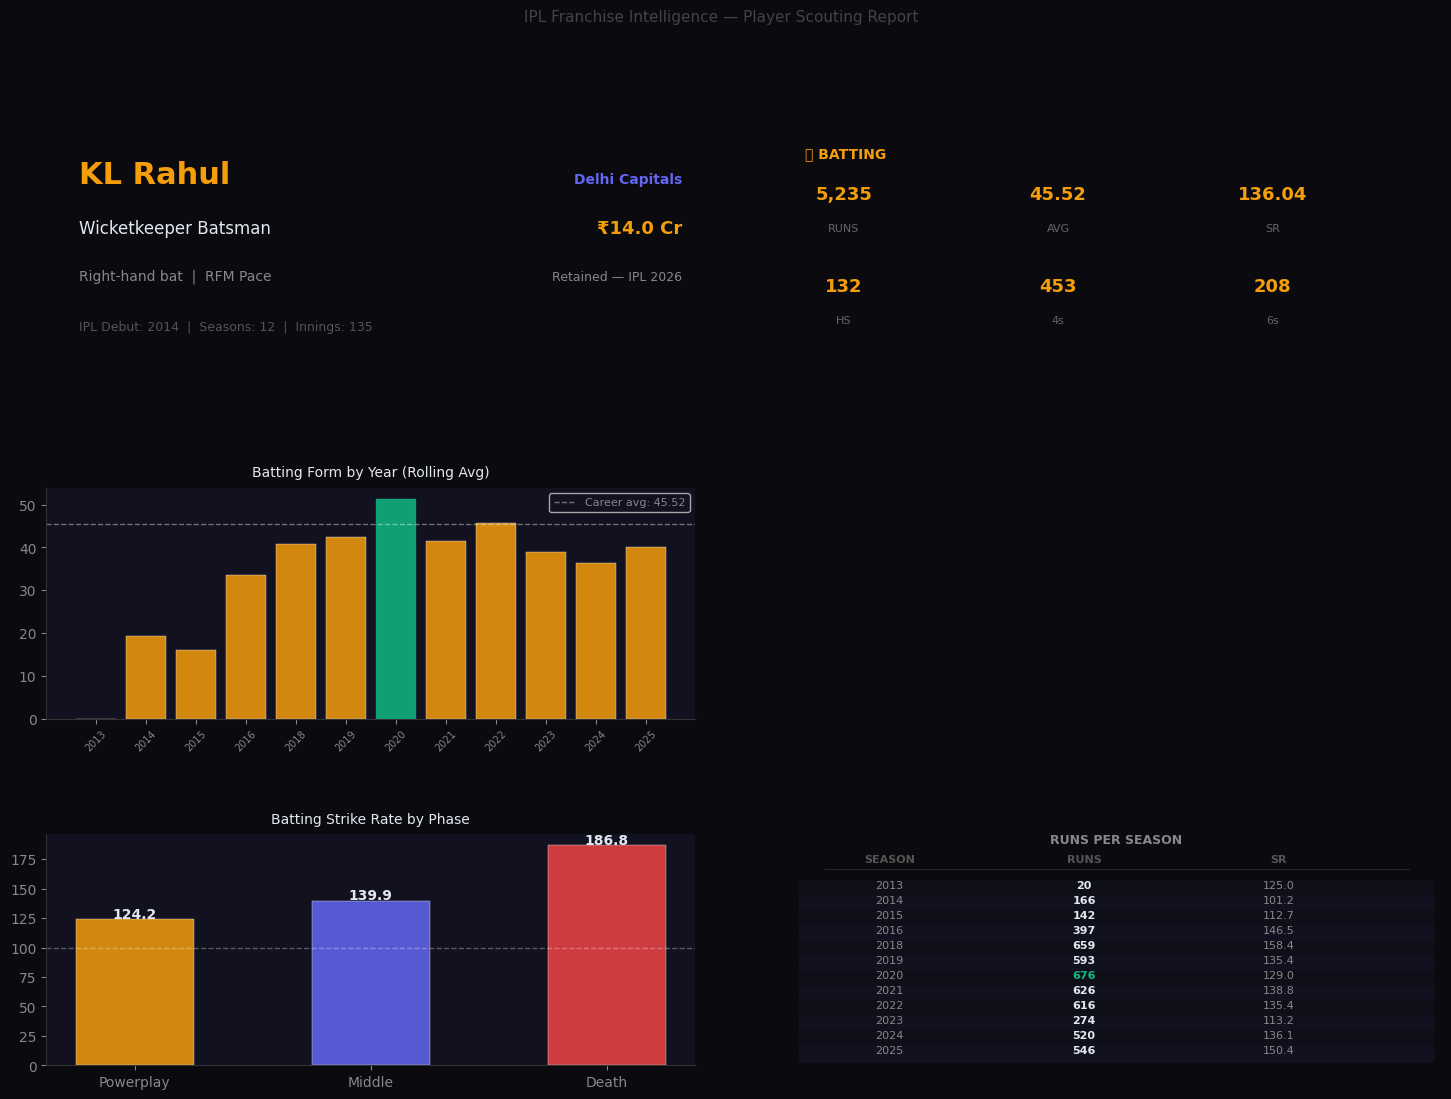

In [41]:
for player in ['KL Rahul']:
    generate_player_card(player)
    plt.close()

In [44]:
# Check how many deliveries exist in 2010
print("Total deliveries:", len(master[master['season']==2025]))
print("Total matches:", master[master['season']==2025]['matchId'].nunique())
print("Sample players:")
print(master[master['season']==2025]['batsman'].value_counts().head(10))

Total deliveries: 17285
Total matches: 74
Sample players:
batsman
B Sai Sudharsan    509
V Kohli            466
SA Yadav           439
Shubman Gill       435
MR Marsh           401
P Simran Singh     376
KL Rahul           369
SS Iyer            360
YBK Jaiswal        359
JC Buttler         337
Name: count, dtype: int64


In [45]:
print("2010 deliveries in original deliveries file:")
deliveries_orig = pd.read_csv('../data/deliveries_updated_ipl_upto_2025.csv')
deliveries_2010 = deliveries_orig[deliveries_orig['date'].str.startswith('2010')]
print(f"Total: {len(deliveries_2010)}")
print(f"Sample players: {deliveries_2010['batsman'].value_counts().head(5)}")

2010 deliveries in original deliveries file:
Total: 14498
Sample players: batsman
JH Kallis       517
SR Tendulkar    489
SC Ganguly      440
SK Raina        387
A Symonds       356
Name: count, dtype: int64


In [50]:
# Rebuild master from scratch using deliveries_fixed which has all 18 seasons

# First check deliveries_fixed has all columns we need
print("deliveries_fixed columns:", list(deliveries_fixed.columns))
print("\nmatches_fixed columns:", list(matches_fixed.columns))

deliveries_fixed columns: ['matchId', 'inning', 'over_ball', 'over', 'ball', 'batting_team', 'bowling_team', 'batsman', 'non_striker', 'bowler', 'batsman_runs', 'extras', 'is_wide', 'is_no_ball', 'byes', 'leg_byes', 'penalty', 'dismissal_kind', 'player_dismissed', 'date', 'season', 'total_runs', 'is_wicket', 'is_four', 'is_six', 'phase']

matches_fixed columns: ['season', 'venue', 'winner_runs', 'toss_winner', 'date', 'city', 'winner', 'method', 'team1', 'toss_decision', 'team2', 'winner_wickets', 'player_of_match', 'match_number', 'matchId']


In [51]:
# Rebuild master completely from deliveries_fixed
master_new = deliveries_fixed.merge(
    matches_fixed[['matchId', 'venue', 'city', 'toss_winner',
                   'toss_decision', 'winner', 'player_of_match', 'method']],
    on='matchId', how='left'
)

master_new['batting_team_won'] = (
    master_new['batting_team'] == master_new['winner']).astype(int)

print("✅ Master rebuilt!")
print(f"Shape: {master_new.shape}")
print(f"\nDeliveries per season:")
print(master_new.groupby('season').size().sort_index().to_string())
print(f"\n2010 sample players:")
print(master_new[master_new['season']==2010]['batsman']
      .value_counts().head(5).to_string())

# Replace master with new version
master = master_new.copy()

# Save
master.to_csv('../data/master_ipl.csv', index=False)
print("\n✅ Saved!")

✅ Master rebuilt!
Shape: (278205, 34)

Deliveries per season:
season
2008.0    13489
2009.0    13606
2010.0    14498
2011.0    17013
2012.0    17767
2013.0    18177
2014.0    14300
2015.0    13652
2016.0    14096
2017.0    13862
2018.0    14286
2019.0    14312
2020.0    14559
2021.0    14425
2022.0    17912
2023.0    17863
2024.0    17103
2025.0    17285

2010 sample players:
batsman
JH Kallis       517
SR Tendulkar    489
SC Ganguly      440
SK Raina        387
A Symonds       356

✅ Saved!


In [53]:
# Rerun seasons count with fixed master
player_teams_new = (master.groupby(['season', 'batsman', 'batting_team'])
                    .size().reset_index(name='balls'))
player_teams_new = player_teams_new[player_teams_new['balls'] >= 5]
player_teams_new.rename(columns={'batsman': 'player', 
                                  'batting_team': 'team'}, inplace=True)

bowler_teams_new = (master.groupby(['season', 'bowler', 'bowling_team'])
                    .size().reset_index(name='balls'))
bowler_teams_new = bowler_teams_new[bowler_teams_new['balls'] >= 5]
bowler_teams_new.rename(columns={'bowler': 'player', 
                                  'bowling_team': 'team'}, inplace=True)

all_teams_new = pd.concat([player_teams_new, bowler_teams_new]).drop_duplicates(
    subset=['season', 'player', 'team'])

# Recount seasons
seasons_new = (all_teams_new.groupby('player')['season']
               .nunique().reset_index())
seasons_new.columns = ['player', 'seasons_played']

# Rebuild transfer history
transfer_new = (all_teams_new.sort_values('season')
                .groupby('player')
                .apply(lambda x: ' → '.join(
                    [f"{int(row['season'])}:{row['team']}"
                     for _, row in x.iterrows()]
                )).reset_index())
transfer_new.columns = ['player', 'franchise_history']

# Update player_career_info
player_career_info = player_career_info.drop(
    columns=['seasons_played', 'franchise_history'], errors='ignore')
player_career_info = player_career_info.merge(seasons_new, on='player', how='left')
player_career_info = player_career_info.merge(transfer_new, on='player', how='left')

# Save
player_career_info.to_csv('../data/player_career_info.csv', index=False)

# Verify
sample = ['V Kohli', 'MS Dhoni', 'RG Sharma', 'SK Raina', 'SV Samson']
print(player_career_info[player_career_info['player'].isin(sample)][
    ['player', 'debut_season', 'seasons_played']
].to_string())

        player  debut_season  seasons_played
417   MS Dhoni        2008.0              18
540  RG Sharma        2008.0              18
615   SK Raina        2008.0              13
646  SV Samson        2013.0              13
710    V Kohli        2008.0              18


In [3]:

venue_player_batting = (master[master['is_wide'] == 0]
                        .groupby(['batsman', 'venue'])
                        .agg(
                            runs=('batsman_runs', 'sum'),
                            balls=('batsman_runs', 'count'),
                            innings=('matchId', 'nunique'),
                            dismissals=('is_wicket', 'sum'),
                            fours=('is_four', 'sum'),
                            sixes=('is_six', 'sum')
                        ).reset_index())

venue_player_batting['avg'] = (venue_player_batting['runs'] / 
                                venue_player_batting['dismissals'].clip(lower=1)).round(2)
venue_player_batting['sr'] = (venue_player_batting['runs'] / 
                               venue_player_batting['balls'] * 100).round(2)


venue_player_batting = venue_player_batting[venue_player_batting['innings'] >= 2]


venue_player_batting['venue_short'] = (venue_player_batting['venue']
                                        .str.split(',').str[0]
                                        .str.replace(' Stadium', '')
                                        .str.replace(' Cricket', '')
                                        .str.replace(' International', ''))


venue_player_batting.to_csv('../data/venue_player_stats.csv', index=False)

print("Venue-specific player stats built!")
print(f"Shape: {venue_player_batting.shape}")
print(f"\nKohli's best venues:")
kohli_venues = (venue_player_batting[venue_player_batting['batsman'] == 'V Kohli']
                .nlargest(5, 'runs')[['venue_short', 'innings', 'runs', 'avg', 'sr']])
print(kohli_venues.to_string())

print(f"\nKohli's worst venues (min 3 innings):")
kohli_worst = (venue_player_batting[
    (venue_player_batting['batsman'] == 'V Kohli') & 
    (venue_player_batting['innings'] >= 3)]
    .nsmallest(5, 'avg')[['venue_short', 'innings', 'runs', 'avg', 'sr']])
print(kohli_worst.to_string())

Venue-specific player stats built!
Shape: (3287, 11)

Kohli's best venues:
           venue_short  innings  runs    avg      sr
6351     M Chinnaswamy       55  1807  35.43  136.79
6352     M Chinnaswamy       19   856  50.35  158.23
6353     M.Chinnaswamy       13   447  34.38  146.56
6382          Wankhede       10   400  66.67  142.86
6345  Feroz Shah Kotla        7   335  55.83  146.29

Kohli's worst venues (min 3 innings):
                     venue_short  innings  runs    avg      sr
6359     Maharashtra Association        3    87  17.40  110.13
6378            St George's Park        3    53  17.67   89.83
6341  Dr DY Patil Sports Academy        4    54  18.00  135.00
6349                JSCA Complex        3    56  18.67  107.69
6373              Sawai Mansingh        7   131  18.71   94.24


In [4]:

venue_player_batting = (master[master['is_wide'] == 0]
                        .groupby(['batsman', 'venue'])
                        .agg(
                            runs=('batsman_runs', 'sum'),
                            balls=('batsman_runs', 'count'),
                            innings=('matchId', 'nunique'),
                            dismissals=('is_wicket', 'sum'),
                            fours=('is_four', 'sum'),
                            sixes=('is_six', 'sum')
                        ).reset_index())

venue_player_batting['avg'] = (venue_player_batting['runs'] /
                                venue_player_batting['dismissals'].clip(lower=1)).round(2)
venue_player_batting['sr'] = (venue_player_batting['runs'] /
                               venue_player_batting['balls'] * 100).round(2)


venue_player_batting = venue_player_batting[venue_player_batting['innings'] >= 3]


venue_player_batting['venue_short'] = (venue_player_batting['venue']
                                        .str.split(',').str[0]
                                        .str.replace(' Stadium', '')
                                        .str.replace(' Cricket', '')
                                        .str.replace(' International', ''))


def add_venue_scores(df, master_df):
    results = []
    
    for batsman, group in df.groupby('batsman'):

        career_data = master_df[(master_df['batsman'] == batsman) & 
                                (master_df['is_wide'] == 0)]
        career_runs = career_data['batsman_runs'].sum()
        career_balls = len(career_data)
        career_dismissals = career_data['is_wicket'].sum()
        
        career_avg = career_runs / max(career_dismissals, 1)
        career_sr = career_runs / max(career_balls, 1) * 100
        

        for _, row in group.iterrows():
            venue_avg = row['avg']
            venue_sr = row['sr']
            

            avg_ratio = venue_avg / max(career_avg, 1)  
            sr_ratio = venue_sr / max(career_sr, 1)
            

            volume_score = min(row['innings'] / 10, 1)  # 
            venue_score = (avg_ratio * 0.4 + sr_ratio * 0.3 + volume_score * 0.3) * 50
            venue_score = round(min(venue_score, 100), 1)
            

            is_happy = (venue_sr - career_sr) >= 15
            

            is_bogey = (venue_avg < career_avg * 0.6) and row['innings'] >= 3
            
            results.append({
                'batsman': batsman,
                'venue': row['venue'],
                'venue_short': row['venue_short'],
                'innings': row['innings'],
                'runs': row['runs'],
                'avg': row['avg'],
                'sr': row['sr'],
                'fours': row['fours'],
                'sixes': row['sixes'],
                'career_avg': round(career_avg, 2),
                'career_sr': round(career_sr, 2),
                'avg_ratio': round(avg_ratio, 3),
                'sr_ratio': round(sr_ratio, 3),
                'venue_score': venue_score,
                'is_happy_ground': is_happy,
                'is_bogey_ground': is_bogey,
            })
    
    return pd.DataFrame(results)

print("Building smart venue scores... (takes 2-3 mins)")
venue_stats_smart = add_venue_scores(venue_player_batting, master)

venue_stats_smart.to_csv('../data/venue_player_stats.csv', index=False)

print(f"Smart venue stats built!")
print(f"Shape: {venue_stats_smart.shape}")


print("\n KOHLI'S HAPPY GROUNDS (venue score ranked):")
kohli_venues = venue_stats_smart[venue_stats_smart['batsman'] == 'V Kohli']
print(kohli_venues.nlargest(5, 'venue_score')[
    ['venue_short', 'innings', 'runs', 'avg', 'sr', 
     'venue_score', 'is_happy_ground']
].to_string())

print("\nKOHLI'S BOGEY GROUNDS:")
kohli_bogey = kohli_venues[kohli_venues['is_bogey_ground'] == True]
print(kohli_bogey[['venue_short', 'innings', 'runs', 'avg', 
                    'sr', 'venue_score']].to_string())

print("\nBUMRAH'S VENUE STATS:")
bumrah_venues = venue_stats_smart[venue_stats_smart['batsman'] == 'JJ Bumrah']
if len(bumrah_venues) == 0:
    print("Bumrah has no batting venue stats (expected for a bowler)")
    

venue_player_bowling = (master[master['is_wide'] == 0]
                        .groupby(['bowler', 'venue'])
                        .agg(
                            wickets=('is_wicket', 'sum'),
                            balls=('total_runs', 'count'),
                            runs_conceded=('total_runs', 'sum'),
                            matches=('matchId', 'nunique')
                        ).reset_index())

venue_player_bowling['economy'] = (venue_player_bowling['runs_conceded'] /
                                    (venue_player_bowling['balls'] / 6)).round(2)
venue_player_bowling['avg'] = (venue_player_bowling['runs_conceded'] /
                                venue_player_bowling['wickets'].clip(lower=1)).round(2)
venue_player_bowling = venue_player_bowling[venue_player_bowling['matches'] >= 2]
venue_player_bowling['venue_short'] = (venue_player_bowling['venue']
                                        .str.split(',').str[0]
                                        .str.replace(' Stadium', '')
                                        .str.replace(' Cricket', '')
                                        .str.replace(' International', ''))


def bowling_venue_score(row, career_eco):
    eco_ratio = career_eco / max(row['economy'], 0.1)  
    wicket_rate = row['wickets'] / max(row['matches'], 1)
    volume = min(row['matches'] / 8, 1)
    score = (eco_ratio * 0.4 + wicket_rate * 0.3 + volume * 0.3) * 50
    return round(min(score, 100), 1)


career_eco = (master[master['is_wide'] == 0]
              .groupby('bowler')
              .apply(lambda x: x['total_runs'].sum() / max(len(x)/6, 0.1))
              .reset_index())
career_eco.columns = ['bowler', 'career_economy']

venue_player_bowling = venue_player_bowling.merge(career_eco, on='bowler', how='left')
venue_player_bowling['venue_score'] = venue_player_bowling.apply(
    lambda x: bowling_venue_score(x, x['career_economy']), axis=1)
venue_player_bowling['is_happy_ground'] = (
    venue_player_bowling['economy'] < 
    venue_player_bowling['career_economy'] * 0.85)
venue_player_bowling['is_bogey_ground'] = (
    venue_player_bowling['economy'] > 
    venue_player_bowling['career_economy'] * 1.2)

venue_player_bowling.to_csv('../data/venue_player_bowling_stats.csv', index=False)

print("\nBUMRAH'S BEST BOWLING VENUES:")
bumrah_bowl = venue_player_bowling[venue_player_bowling['bowler'] == 'JJ Bumrah']
print(bumrah_bowl.nlargest(5, 'venue_score')[
    ['venue_short', 'matches', 'wickets', 'economy', 
     'venue_score', 'is_happy_ground']
].to_string())

Building smart venue scores... (takes 2-3 mins)
Smart venue stats built!
Shape: (1925, 16)

 KOHLI'S HAPPY GROUNDS (venue score ranked):
           venue_short  innings  runs     avg      sr  venue_score  is_happy_ground
1806    Sawai Mansingh        3   193  193.00  141.91        100.0            False
1810          Wankhede       10   400   66.67  142.86         66.6            False
1796     M Chinnaswamy       19   856   50.35  158.23         59.7             True
1792  Feroz Shah Kotla        7   335   55.83  146.29         56.8            False
1790      Eden Gardens        9   307   43.86  130.08         51.5            False

KOHLI'S BOGEY GROUNDS:
                     venue_short  innings  runs    avg      sr  venue_score
1788  Dr DY Patil Sports Academy        4    54  18.00  135.00         30.8
1793                JSCA Complex        3    56  18.67  107.69         26.6
1794                   Kingsmead        4    75  18.75  117.19         29.2
1801     Maharashtra Associatio

In [7]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error
import pickle



print("Building prediction dataset...")

match_batting = (master[master['is_wide'] == 0]
                 .groupby(['matchId', 'date', 'season', 'batsman', 
                           'batting_team', 'bowling_team', 'venue'])
                 .agg(
                     runs=('batsman_runs', 'sum'),
                     balls=('batsman_runs', 'count'),
                     dismissed=('is_wicket', 'sum')
                 ).reset_index())

match_batting['sr'] = (match_batting['runs'] / 
                        match_batting['balls'] * 100).round(2)
match_batting['date'] = pd.to_datetime(match_batting['date'])
match_batting = match_batting.sort_values(['batsman', 'date']).reset_index(drop=True)


batting_features_slim = batting_features[['matchId', 'batsman', 'avg_last5', 
                                           'sr_last5', 'form_score', 'form_sr',
                                           'career_avg', 'career_sr', 
                                           'consistency', 'boundary_rate']]
match_batting = match_batting.merge(batting_features_slim, 
                                     on=['matchId', 'batsman'], how='left')

venue_slim = venue_stats_smart[['batsman', 'venue', 'avg', 'sr', 
                                  'venue_score', 'is_happy_ground', 
                                  'is_bogey_ground']].rename(
    columns={'avg': 'venue_avg', 'sr': 'venue_sr'})
match_batting = match_batting.merge(venue_slim, 
                                     on=['batsman', 'venue'], how='left')


opposition_stats = (master[master['is_wide'] == 0]
                    .groupby(['batsman', 'bowling_team'])
                    .agg(
                        opp_runs=('batsman_runs', 'sum'),
                        opp_balls=('batsman_runs', 'count'),
                        opp_dismissals=('is_wicket', 'sum')
                    ).reset_index())
opposition_stats['opp_avg'] = (opposition_stats['opp_runs'] / 
                                opposition_stats['opp_dismissals'].clip(lower=1)).round(2)
opposition_stats['opp_sr'] = (opposition_stats['opp_runs'] / 
                               opposition_stats['opp_balls'] * 100).round(2)

match_batting = match_batting.merge(
    opposition_stats[['batsman', 'bowling_team', 'opp_avg', 'opp_sr']],
    on=['batsman', 'bowling_team'], how='left')

match_batting['venue_avg'] = match_batting['venue_avg'].fillna(
    match_batting['career_avg'])
match_batting['venue_sr'] = match_batting['venue_sr'].fillna(
    match_batting['career_sr'])
match_batting['opp_avg'] = match_batting['opp_avg'].fillna(
    match_batting['career_avg'])
match_batting['opp_sr'] = match_batting['opp_sr'].fillna(
    match_batting['career_sr'])
match_batting['venue_score'] = match_batting['venue_score'].fillna(50)
match_batting['is_happy_ground'] = match_batting['is_happy_ground'].fillna(False).astype(int)
match_batting['is_bogey_ground'] = match_batting['is_bogey_ground'].fillna(False).astype(int)
match_batting = match_batting.fillna(0)

print(f"Prediction dataset built: {match_batting.shape}")


feature_cols = [
    'avg_last5', 'sr_last5', 'form_score', 'form_sr',
    'career_avg', 'career_sr', 'consistency',
    'venue_avg', 'venue_sr', 'venue_score',
    'is_happy_ground', 'is_bogey_ground',
    'opp_avg', 'opp_sr', 'boundary_rate'
]


match_batting['season'] = match_batting['season'].fillna(
    match_batting['date'].dt.year)
train = match_batting[match_batting['season'] <= 2021]
test = match_batting[match_batting['season'] >= 2023]


qualified = (match_batting.groupby('batsman')['runs']
             .count()[lambda x: x >= 10].index)
train_q = train[train['batsman'].isin(qualified)]
test_q = test[test['batsman'].isin(qualified)]

X_train = train_q[feature_cols].fillna(0)
y_train = train_q['runs']
X_test = test_q[feature_cols].fillna(0)
y_test = test_q['runs']


print("Training performance predictor...")
gbm = GradientBoostingRegressor(
    n_estimators=200, max_depth=4,
    learning_rate=0.05, subsample=0.8,
    random_state=42
)
gbm.fit(X_train, y_train)

train_mae = mean_absolute_error(y_train, gbm.predict(X_train))
test_mae = mean_absolute_error(y_test, gbm.predict(X_test))

print(f"Model trained!")
print(f"Train MAE: {train_mae:.2f} runs")
print(f"Test MAE:  {test_mae:.2f} runs")

with open('../models/performance_predictor.pkl', 'wb') as f:
    pickle.dump(gbm, f)

match_batting.to_csv('../data/match_batting_features.csv', index=False)
print("Model and data saved!")

Building prediction dataset...
Prediction dataset built: (17336, 26)
Training performance predictor...
Model trained!
Train MAE: 12.55 runs
Test MAE:  14.45 runs
Model and data saved!


In [15]:
def predict_player_performance(player_name, venue, opponent_team):
    """Predict player performance in next match"""
    
    feature_cols = [
        'avg_last5', 'sr_last5', 'form_score', 'form_sr',
        'career_avg', 'career_sr', 'consistency', 'boundary_rate',
        'venue_avg', 'venue_sr', 'venue_score',
        'is_happy_ground', 'is_bogey_ground',
        'opp_avg', 'opp_sr'
    ]
    
    # Get player's latest form
    latest_form = batting_features[
        batting_features['batsman'] == player_name
    ].tail(1)
    
    if len(latest_form) == 0:
        print(f"No batting data found for {player_name}")
        return None
    
    # Extract first part of venue name for matching
    venue_key = venue.split(',')[0].strip()
    
    # Get venue stats
    venue_data = venue_stats_smart[
        (venue_stats_smart['batsman'] == player_name) &
        (venue_stats_smart['venue'].str.contains(venue_key, na=False, regex=False))
    ]
    
    if len(venue_data) == 0:
        venue_data = venue_stats_smart[
            (venue_stats_smart['batsman'] == player_name) &
            (venue_stats_smart['venue_short'].str.contains(
                venue_key[:10], na=False, regex=False))
        ]
    
    # Get opposition stats
    opp_data = opposition_stats[
        (opposition_stats['batsman'] == player_name) &
        (opposition_stats['bowling_team'] == opponent_team)
    ]
    
    career_avg = latest_form['career_avg'].values[0]
    career_sr = latest_form['career_sr'].values[0]
    
    # Build feature vector
    features = {
        'avg_last5': latest_form['avg_last5'].values[0],
        'sr_last5': latest_form['sr_last5'].values[0],
        'form_score': latest_form['form_score'].values[0],
        'form_sr': latest_form['form_sr'].values[0],
        'career_avg': career_avg,
        'career_sr': career_sr,
        'consistency': latest_form['consistency'].values[0],
        'boundary_rate': latest_form['boundary_rate'].values[0],
        'venue_avg': float(venue_data['venue_avg'].mean()) if len(venue_data) > 0 else career_avg,
        'venue_sr': float(venue_data['venue_sr'].mean()) if len(venue_data) > 0 else career_sr,
        'venue_score': float(venue_data['venue_score'].mean()) if len(venue_data) > 0 else 50.0,
        'is_happy_ground': int(venue_data['is_happy_ground'].any()) if len(venue_data) > 0 else 0,
        'is_bogey_ground': int(venue_data['is_bogey_ground'].any()) if len(venue_data) > 0 else 0,
        'opp_avg': float(opp_data['opp_avg'].values[0]) if len(opp_data) > 0 else career_avg,
        'opp_sr': float(opp_data['opp_sr'].values[0]) if len(opp_data) > 0 else career_sr,
    }
    
    X = pd.DataFrame([features])[feature_cols]
    predicted_runs = gbm.predict(X)[0]
    
    consistency = latest_form['consistency'].values[0]
    std_dev = max(consistency * 0.8, 8)
    lower = max(0, predicted_runs - std_dev)
    upper = predicted_runs + std_dev
    
    prob_50plus = max(0, min(1, (predicted_runs - 50) / 30 + 0.5))
    prob_duck = max(0, min(1, 0.15 - (predicted_runs / 200)))
    
    return {
        'player': player_name,
        'venue': venue_key,
        'opponent': opponent_team,
        'predicted_runs': round(predicted_runs, 1),
        'lower_bound': round(lower, 1),
        'upper_bound': round(upper, 1),
        'confidence_range': f"{round(lower)}–{round(upper)} runs",
        'form_score': round(float(latest_form['form_score'].values[0]), 1),
        'venue_score': round(float(features['venue_score']), 1),
        'is_happy_ground': bool(features['is_happy_ground']),
        'is_bogey_ground': bool(features['is_bogey_ground']),
        'prob_50plus': round(prob_50plus * 100, 1),
        'prob_duck': round(prob_duck * 100, 1),
        'recommendation': 'PLAY' if predicted_runs >= 30 else
                         'CONSIDER' if predicted_runs >= 20 else 'RISK'
    }

# ── TEST PREDICTIONS ───────────────────────────────────
print("=== NEXT MATCH PERFORMANCE PREDICTIONS ===\n")

test_cases = [
    ('V Kohli',      'M Chinnaswamy Stadium, Bengaluru', 'Mumbai Indians'),
    ('V Kohli',      'Wankhede Stadium, Mumbai',         'Chennai Super Kings'),
    ('RR Pant',      'Arun Jaitley Stadium, Delhi',      'Rajasthan Royals'),
    ('YBK Jaiswal',  'Sawai Mansingh Stadium, Jaipur',   'Mumbai Indians'),
    ('Shubman Gill', 'Narendra Modi Stadium, Ahmedabad', 'Chennai Super Kings'),
]

for player, venue, opponent in test_cases:
    result = predict_player_performance(player, venue, opponent)
    if result:
        print(f"🏏 {result['player']} vs {result['opponent']} @ {result['venue']}")
        print(f"   Predicted: {result['predicted_runs']} runs  "
              f"(range: {result['confidence_range']})")
        print(f"   Form Score: {result['form_score']}  |  "
              f"Venue Score: {result['venue_score']}")
        print(f"   Happy Ground: {result['is_happy_ground']}  |  "
              f"Bogey Ground: {result['is_bogey_ground']}")
        print(f"   P(50+): {result['prob_50plus']}%  |  "
              f"Recommendation: {result['recommendation']}")
        print()

=== NEXT MATCH PERFORMANCE PREDICTIONS ===



ValueError: The feature names should match those that were passed during fit.
Feature names must be in the same order as they were in fit.


In [13]:
# Check what venues exist for Kohli
print("Kohli venues in venue_stats_smart:")
print(venue_stats_smart[venue_stats_smart['batsman']=='V Kohli']['venue'].tolist())

Kohli venues in venue_stats_smart:
['Bharat Ratna Shri Atal Bihari Vajpayee Ekana Cricket Stadium, Lucknow', 'Brabourne Stadium, Mumbai', 'Dr DY Patil Sports Academy, Mumbai', 'Dubai International Cricket Stadium', 'Eden Gardens', 'Eden Gardens, Kolkata', 'Feroz Shah Kotla', 'JSCA International Stadium Complex', 'Kingsmead', 'M Chinnaswamy Stadium', 'M Chinnaswamy Stadium, Bengaluru', 'M.Chinnaswamy Stadium', 'MA Chidambaram Stadium, Chepauk', 'MA Chidambaram Stadium, Chepauk, Chennai', 'Maharashtra Cricket Association Stadium', 'Maharashtra Cricket Association Stadium, Pune', 'Narendra Modi Stadium, Ahmedabad', 'Punjab Cricket Association Stadium, Mohali', 'Rajiv Gandhi International Stadium, Uppal', 'Sawai Mansingh Stadium', 'Sawai Mansingh Stadium, Jaipur', 'Sharjah Cricket Stadium', 'Sheikh Zayed Stadium', "St George's Park", 'Wankhede Stadium', 'Wankhede Stadium, Mumbai']


In [19]:
def predict_player_performance(player_name, venue, opponent_team):
    """Predict player performance in next match"""
    
    feature_cols = [
    'avg_last5', 'sr_last5', 'form_score', 'form_sr',
    'career_avg', 'career_sr', 'consistency',
    'venue_avg', 'venue_sr', 'venue_score',
    'is_happy_ground', 'is_bogey_ground',
    'opp_avg', 'opp_sr', 'boundary_rate'
]
    
    # Get player's latest form
    latest_form = batting_features[
        batting_features['batsman'] == player_name
    ].tail(1)
    
    if len(latest_form) == 0:
        print(f"No batting data found for {player_name}")
        return None
    
    # Extract first part of venue name for matching
    venue_key = venue.split(',')[0].strip()
    
    # Get venue stats
    venue_data = venue_stats_smart[
        (venue_stats_smart['batsman'] == player_name) &
        (venue_stats_smart['venue'].str.contains(venue_key, na=False, regex=False))
    ]
    
    if len(venue_data) == 0:
        venue_data = venue_stats_smart[
            (venue_stats_smart['batsman'] == player_name) &
            (venue_stats_smart['venue_short'].str.contains(
                venue_key[:10], na=False, regex=False))
        ]
    
    # Get opposition stats
    opp_data = opposition_stats[
        (opposition_stats['batsman'] == player_name) &
        (opposition_stats['bowling_team'] == opponent_team)
    ]
    
    career_avg = latest_form['career_avg'].values[0]
    career_sr = latest_form['career_sr'].values[0]
    
    # Build feature vector
    features = {
        'avg_last5': latest_form['avg_last5'].values[0],
        'sr_last5': latest_form['sr_last5'].values[0],
        'form_score': latest_form['form_score'].values[0],
        'form_sr': latest_form['form_sr'].values[0],
        'career_avg': career_avg,
        'career_sr': career_sr,
        'consistency': latest_form['consistency'].values[0],
        'boundary_rate': latest_form['boundary_rate'].values[0],
        'venue_avg': float(venue_data['venue_avg'].mean()) if len(venue_data) > 0 else career_avg,
        'venue_sr': float(venue_data['venue_sr'].mean()) if len(venue_data) > 0 else career_sr,
        'venue_score': float(venue_data['venue_score'].mean()) if len(venue_data) > 0 else 50.0,
        'is_happy_ground': int(venue_data['is_happy_ground'].any()) if len(venue_data) > 0 else 0,
        'is_bogey_ground': int(venue_data['is_bogey_ground'].any()) if len(venue_data) > 0 else 0,
        'opp_avg': float(opp_data['opp_avg'].values[0]) if len(opp_data) > 0 else career_avg,
        'opp_sr': float(opp_data['opp_sr'].values[0]) if len(opp_data) > 0 else career_sr,
    }
    
    X = pd.DataFrame([features])[feature_cols]
    predicted_runs = gbm.predict(X)[0]
    
    consistency = latest_form['consistency'].values[0]
    std_dev = max(consistency * 0.8, 8)
    lower = max(0, predicted_runs - std_dev)
    upper = predicted_runs + std_dev
    
    prob_50plus = max(0, min(1, (predicted_runs - 50) / 30 + 0.5))
    prob_duck = max(0, min(1, 0.15 - (predicted_runs / 200)))
    
    return {
        'player': player_name,
        'venue': venue_key,
        'opponent': opponent_team,
        'predicted_runs': round(predicted_runs, 1),
        'lower_bound': round(lower, 1),
        'upper_bound': round(upper, 1),
        'confidence_range': f"{round(lower)}–{round(upper)} runs",
        'form_score': round(float(latest_form['form_score'].values[0]), 1),
        'venue_score': round(float(features['venue_score']), 1),
        'is_happy_ground': bool(features['is_happy_ground']),
        'is_bogey_ground': bool(features['is_bogey_ground']),
        'prob_50plus': round(prob_50plus * 100, 1),
        'prob_duck': round(prob_duck * 100, 1),
        'recommendation': 'PLAY' if predicted_runs >= 30 else
                         'CONSIDER' if predicted_runs >= 20 else 'RISK'
    }

# ── TEST PREDICTIONS ───────────────────────────────────
print("=== NEXT MATCH PERFORMANCE PREDICTIONS ===\n")

test_cases = [
    ('V Kohli',      'M Chinnaswamy Stadium, Bengaluru', 'Mumbai Indians'),
    ('V Kohli',      'Wankhede Stadium, Mumbai',         'Chennai Super Kings'),
    ('RR Pant',      'Arun Jaitley Stadium, Delhi',      'Rajasthan Royals'),
    ('YBK Jaiswal',  'Sawai Mansingh Stadium, Jaipur',   'Mumbai Indians'),
    ('Shubman Gill', 'Narendra Modi Stadium, Ahmedabad', 'Chennai Super Kings'),
]

for player, venue, opponent in test_cases:
    result = predict_player_performance(player, venue, opponent)
    if result:
        print(f"{result['player']} vs {result['opponent']} @ {result['venue']}")
        print(f"   Predicted: {result['predicted_runs']} runs  "
              f"(range: {result['confidence_range']})")
        print(f"   Form Score: {result['form_score']}  |  "
              f"Venue Score: {result['venue_score']}")
        print(f"   Happy Ground: {result['is_happy_ground']}  |  "
              f"Bogey Ground: {result['is_bogey_ground']}")
        print(f"   P(50+): {result['prob_50plus']}%  |  "
              f"Recommendation: {result['recommendation']}")
        print()

=== NEXT MATCH PERFORMANCE PREDICTIONS ===

V Kohli vs Mumbai Indians @ M Chinnaswamy Stadium
   Predicted: 26.5 runs  (range: 5–48 runs)
   Form Score: 44.0  |  Venue Score: 54.5
   Happy Ground: True  |  Bogey Ground: False
   P(50+): 0%  |  Recommendation: CONSIDER

V Kohli vs Chennai Super Kings @ Wankhede Stadium
   Predicted: 30.8 runs  (range: 9–53 runs)
   Form Score: 44.0  |  Venue Score: 56.6
   Happy Ground: False  |  Bogey Ground: False
   P(50+): 0%  |  Recommendation: PLAY

RR Pant vs Rajasthan Royals @ Arun Jaitley Stadium
   Predicted: 42.8 runs  (range: 23–62 runs)
   Form Score: 15.6  |  Venue Score: 54.0
   Happy Ground: True  |  Bogey Ground: False
   P(50+): 26.0%  |  Recommendation: PLAY

YBK Jaiswal vs Mumbai Indians @ Sawai Mansingh Stadium
   Predicted: 40.8 runs  (range: 18–63 runs)
   Form Score: 42.4  |  Venue Score: 59.8
   Happy Ground: False  |  Bogey Ground: False
   P(50+): 19.2%  |  Recommendation: PLAY

Shubman Gill vs Chennai Super Kings @ Narendra M

In [20]:
# Fix probability formula and save all Module 1 outputs
import pickle

def calc_prob_50plus(predicted, std_dev):
    """Use normal distribution approximation"""
    from scipy import stats
    prob = 1 - stats.norm.cdf(50, loc=predicted, scale=std_dev)
    return round(max(0, min(100, prob * 100)), 1)

def calc_prob_duck(predicted, std_dev):
    from scipy import stats
    prob = stats.norm.cdf(5, loc=predicted, scale=std_dev)
    return round(max(0, min(100, prob * 100)), 1)

# Test fixed probabilities
from scipy import stats
test_pred = 26.5
test_std = 21.5
print(f"P(50+) for predicted={test_pred}, std={test_std}: "
      f"{calc_prob_50plus(test_pred, test_std)}%")
print(f"P(duck) for predicted={test_pred}, std={test_std}: "
      f"{calc_prob_duck(test_pred, test_std)}%")

# Save all Module 1 data files
venue_stats_smart.to_csv('../data/venue_player_stats.csv', index=False)
venue_player_bowling.to_csv('../data/venue_player_bowling_stats.csv', index=False)
opposition_stats.to_csv('../data/opposition_stats.csv', index=False)

with open('../models/performance_predictor.pkl', 'wb') as f:
    pickle.dump(gbm, f)

print("\n All Module 1 files saved!")
print("\nModule 1 complete — files produced:")
print("  → player_dna.csv")
print("  → player_metadata.csv")
print("  → player_career_info.csv")
print("  → venue_player_stats.csv")
print("  → venue_player_bowling_stats.csv")
print("  → opposition_stats.csv")
print("  → current_ipl_squads.csv")
print("  → performance_predictor.pkl")
print("  → reports/player_card_*.png")

P(50+) for predicted=26.5, std=21.5: 13.7%
P(duck) for predicted=26.5, std=21.5: 15.9%

 All Module 1 files saved!

Module 1 complete — files produced:
  → player_dna.csv
  → player_metadata.csv
  → player_career_info.csv
  → venue_player_stats.csv
  → venue_player_bowling_stats.csv
  → opposition_stats.csv
  → current_ipl_squads.csv
  → performance_predictor.pkl
  → reports/player_card_*.png


✅ Saved: ../reports/player_card_V_Kohli.png


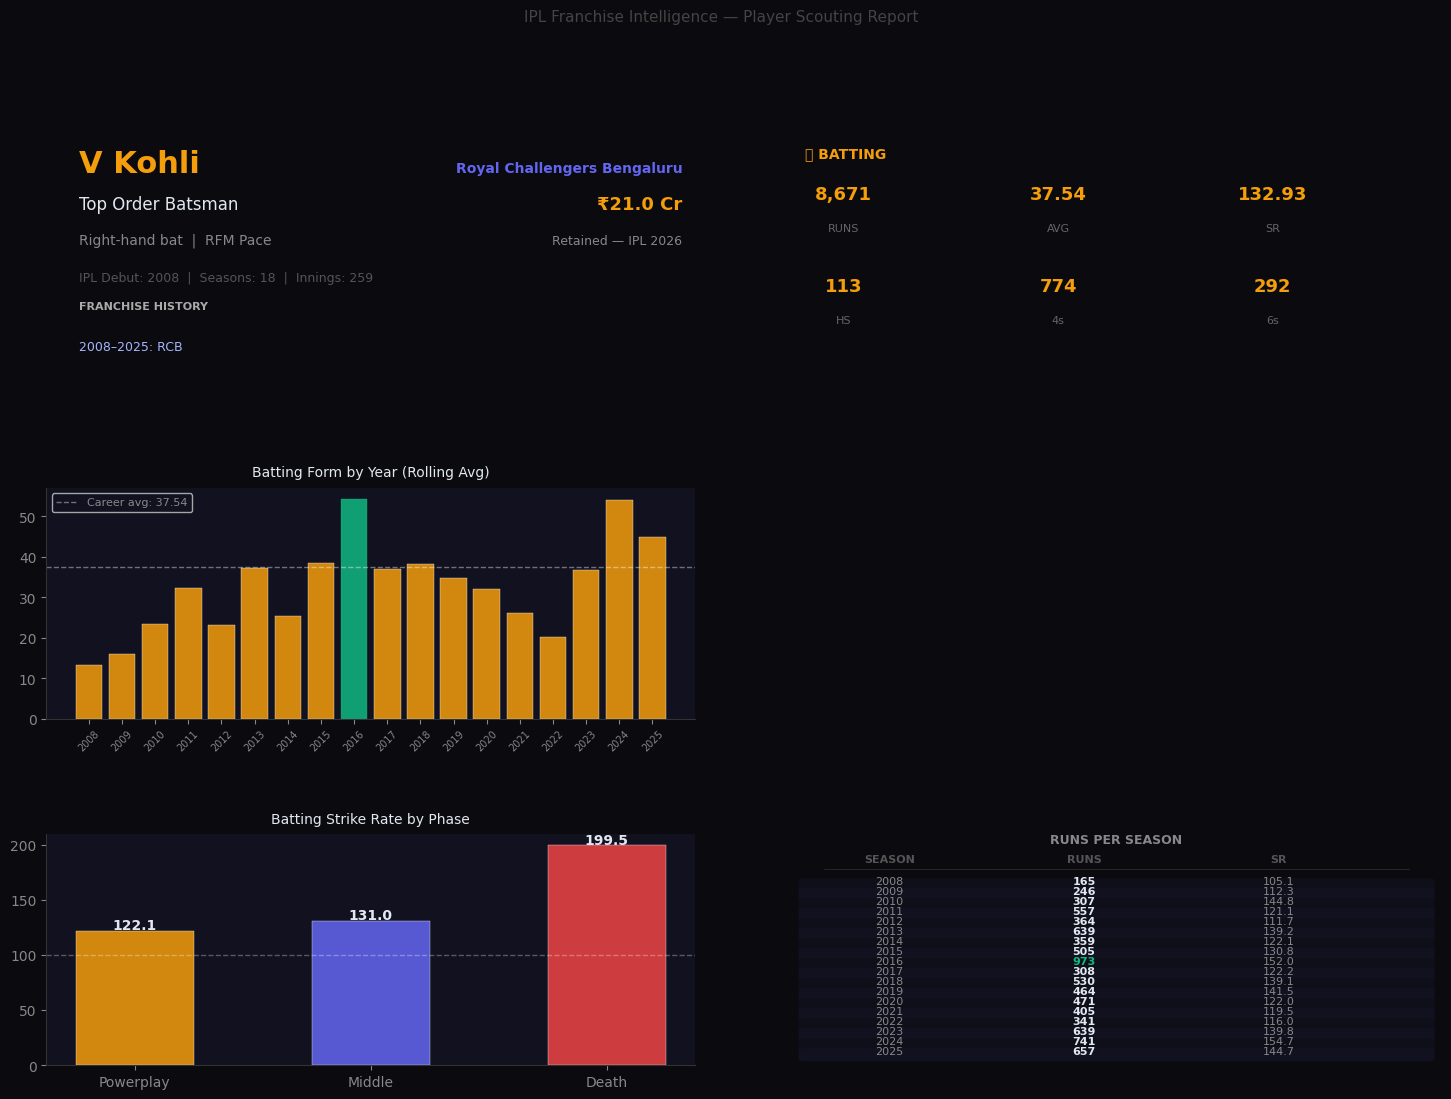

In [ ]:
for player in ['V Kohli']: #Add any new player to test here
    generate_player_card(player)
    plt.close()